In [1]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn pillow tqdm pycocotools
%pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu121
%pip install -q transformers sentencepiece

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')
import json
import hashlib
import random
import zipfile
import urllib.request
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFilter, ImageEnhance
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from pycocotools.coco import COCO
from transformers import CLIPModel, AutoTokenizer, AutoImageProcessor
from torchvision import models
from torchvision import models

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Stable settings for GPU notebook runs: avoid strict deterministic CuBLAS errors.
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
    try:
        torch.use_deterministic_algorithms(False)
    except Exception:
        pass

seed_everything(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE =', DEVICE)

CFG = {
    'seed': 42,
    'min_classes': 5,
    'min_samples_per_class': 120,
    'min_total_samples_required': 3000,
    'num_classes_keep': 8,
    'batch_size_mm': 32,
    'few_shot_k_per_class': 16,
    'clip_head_epochs': 10,
    'clip_head_batch_size': 8,
    'lr_clip_head': 3e-5,
    'num_workers': 0,
}

ROOT = Path.cwd()
DRIVE_DATA_ROOT = Path('/content/drive/MyDrive/Deep Learning/data/multimodal_data')
DATA_DIR = DRIVE_DATA_ROOT
RAW_DIR = DATA_DIR / 'raw' / 'coco'
WORK_DIR = DATA_DIR / 'work'
OUT_DIR = ROOT / 'outputs'
for p in [DATA_DIR, RAW_DIR, WORK_DIR, OUT_DIR]:
    p.mkdir(parents=True, exist_ok=True)
CFG['batch_size_mm'] = 96 if torch.cuda.is_available() else 16
CFG['num_workers'] = 4 if torch.cuda.is_available() else 0

DEVICE = cuda


In [5]:
# def coco_url_candidates(url):
#     candidates = [url]
#     if url.startswith('https://images.cocodataset.org/'):
#         candidates.append(url.replace('https://', 'http://', 1))
#     return candidates


# def download_file(url, out_path, retries=2):
#     out_path.parent.mkdir(parents=True, exist_ok=True)
#     if out_path.exists():
#         print('Exists:', out_path.name)
#         return

#     errors = []
#     for candidate_url in coco_url_candidates(url):
#         for attempt in range(1, retries + 1):
#             try:
#                 print(f'Downloading ({attempt}/{retries}):', candidate_url)
#                 urllib.request.urlretrieve(candidate_url, out_path)
#                 return
#             except Exception as e:
#                 errors.append(f'{candidate_url} (attempt {attempt}): {e}')
#                 if out_path.exists():
#                     try:
#                         out_path.unlink()
#                     except Exception:
#                         pass
#                 print('Download failed:', e)

#     msg = chr(10).join(errors[-6:])
#     raise RuntimeError(f'Failed to download {out_path.name}. Last errors:' + chr(10) + msg)


# def unzip_file(zip_path, target_dir):
#     target_dir.mkdir(parents=True, exist_ok=True)
#     marker = target_dir / f'.{zip_path.stem}.unzipped'
#     if marker.exists():
#         print('Already unzipped:', zip_path.name)
#         return
#     print('Extracting:', zip_path.name)
#     with zipfile.ZipFile(zip_path, 'r') as zf:
#         zf.extractall(target_dir)
#     marker.touch()


# urls = {
#     'train2017.zip': 'http://images.cocodataset.org/zips/train2017.zip',
#     'val2017.zip': 'http://images.cocodataset.org/zips/val2017.zip',
#     'annotations_trainval2017.zip': 'http://images.cocodataset.org/annotations/annotations_trainval2017.zip',
# }

# for fn, url in urls.items():
#     download_file(url, RAW_DIR / fn)

# unzip_file(RAW_DIR / 'train2017.zip', RAW_DIR)
# unzip_file(RAW_DIR / 'val2017.zip', RAW_DIR)
# unzip_file(RAW_DIR / 'annotations_trainval2017.zip', RAW_DIR)

In [6]:
img_dirs = {
    'train2017': RAW_DIR / 'train2017',
    'val2017': RAW_DIR / 'val2017',
}
inst_jsons = {
    'train2017': RAW_DIR / 'annotations' / 'instances_train2017.json',
    'val2017': RAW_DIR / 'annotations' / 'instances_val2017.json',
}
cap_jsons = {
    'train2017': RAW_DIR / 'annotations' / 'captions_train2017.json',
    'val2017': RAW_DIR / 'annotations' / 'captions_val2017.json',
}

for split in ['train2017', 'val2017']:
    print(f'{split} dir exists:', img_dirs[split].exists())
    print(f'{split} instances exists:', inst_jsons[split].exists())
    print(f'{split} captions exists:', cap_jsons[split].exists())

train2017 dir exists: True
train2017 instances exists: True
train2017 captions exists: True
val2017 dir exists: True
val2017 instances exists: True
val2017 captions exists: True


In [7]:
rows = []
for split in ['train2017', 'val2017']:
    coco_inst = COCO(str(inst_jsons[split]))
    coco_cap = COCO(str(cap_jsons[split]))

    img_ids = sorted(list(set(coco_inst.getImgIds()) & set(coco_cap.getImgIds())))

    # Limit train2017 to 2000 samples
    if split == 'train2017':
        img_ids = img_ids[:3000]

    print(f'[{split}] Using image ids:', len(img_ids))

    cats = coco_inst.loadCats(coco_inst.getCatIds())
    catid_to_super = {c['id']: c['supercategory'] for c in cats}

    for img_id in tqdm(img_ids, desc=f'Build rows {split}'):
        ann_ids = coco_inst.getAnnIds(imgIds=[img_id], iscrowd=None)
        anns = coco_inst.loadAnns(ann_ids)
        if len(anns) == 0:
            continue

        super_counts = Counter()
        for a in anns:
            super_counts[catid_to_super[a['category_id']]] += 1
        label_raw = super_counts.most_common(1)[0][0]

        cap_ids = coco_cap.getAnnIds(imgIds=[img_id])
        caps = coco_cap.loadAnns(cap_ids)
        if len(caps) == 0:
            continue
        caption = sorted([c['caption'] for c in caps], key=len, reverse=True)[0].strip()
        if caption == '':
            continue

        img_info = coco_inst.loadImgs([img_id])[0]
        image_path = img_dirs[split] / img_info['file_name']
        if not image_path.exists():
            continue

        rows.append({
            'image_id': img_id,
            'image_path': str(image_path),
            'text': caption,
            'label_raw': label_raw,
            'coco_split': split,
        })

df = pd.DataFrame(rows)
print('Rows before filtering:', len(df))
print('Classes before filtering:', df['label_raw'].nunique())
print('Rows by COCO split:')
display(df['coco_split'].value_counts())

label_counts = df['label_raw'].value_counts()
eligible = label_counts[label_counts >= CFG['min_samples_per_class']]
if len(eligible) < CFG['min_classes']:
    raise ValueError('Khong du so class sau filtering, giam min_samples_per_class hoac mo rong du lieu.')

selected_labels = eligible.head(CFG['num_classes_keep']).index.tolist()
df = df[df['label_raw'].isin(selected_labels)].copy()

assert df['label_raw'].nunique() >= CFG['min_classes']
assert len(df) >= CFG['min_total_samples_required']

train_df, tmp_df = train_test_split(df, test_size=0.30, stratify=df['label_raw'], random_state=CFG['seed'])
val_df, test_df = train_test_split(tmp_df, test_size=0.50, stratify=tmp_df['label_raw'], random_state=CFG['seed'])

le = LabelEncoder()
le.fit(train_df['label_raw'])
for part in [train_df, val_df, test_df]:
    part['label'] = le.transform(part['label_raw'])

id2label = {int(i): c for i, c in enumerate(le.classes_)}
print('Final classes:', len(le.classes_))
print('Split sizes:', len(train_df), len(val_df), len(test_df))
display(train_df['label_raw'].value_counts())

loading annotations into memory...
Done (t=71.57s)
creating index...
index created!
loading annotations into memory...
Done (t=2.55s)
creating index...
index created!
[train2017] Using image ids: 3000


Build rows train2017:   0%|          | 0/3000 [00:00<?, ?it/s]

loading annotations into memory...
Done (t=1.74s)
creating index...
index created!
loading annotations into memory...
Done (t=0.61s)
creating index...
index created!
[val2017] Using image ids: 5000


Build rows val2017:   0%|          | 0/5000 [00:00<?, ?it/s]

Rows before filtering: 6108
Classes before filtering: 12
Rows by COCO split:


,count
coco_split,
val2017,4952
train2017,1156


Final classes: 8
Split sizes: 3781 810 811


,count
label_raw,
person,1205
animal,627
vehicle,549
kitchen,347
furniture,344
food,285
indoor,260
electronic,164


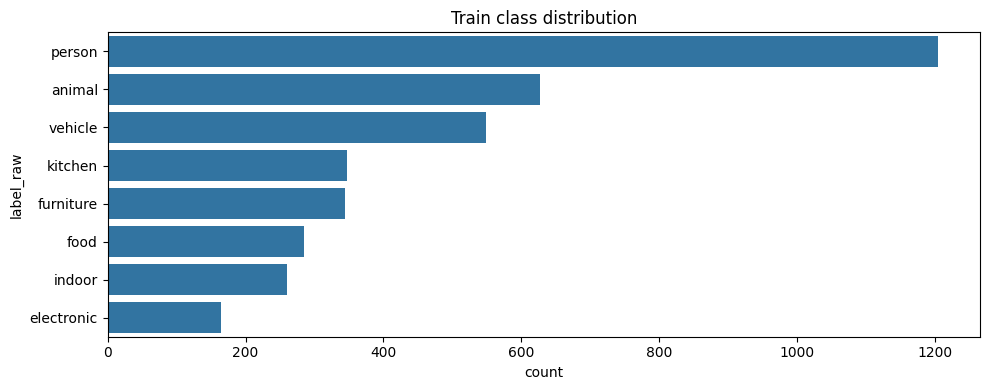

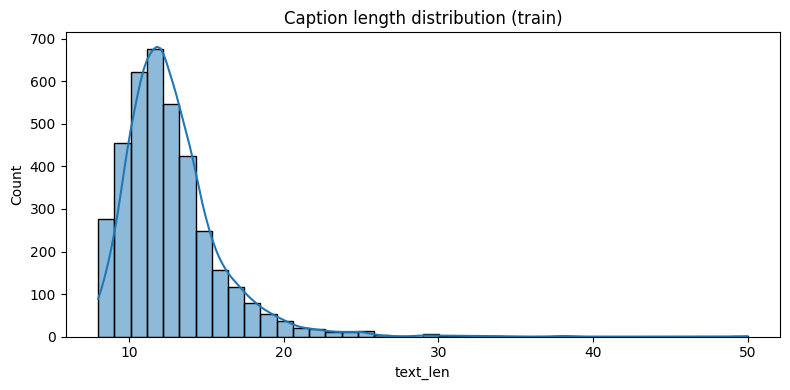

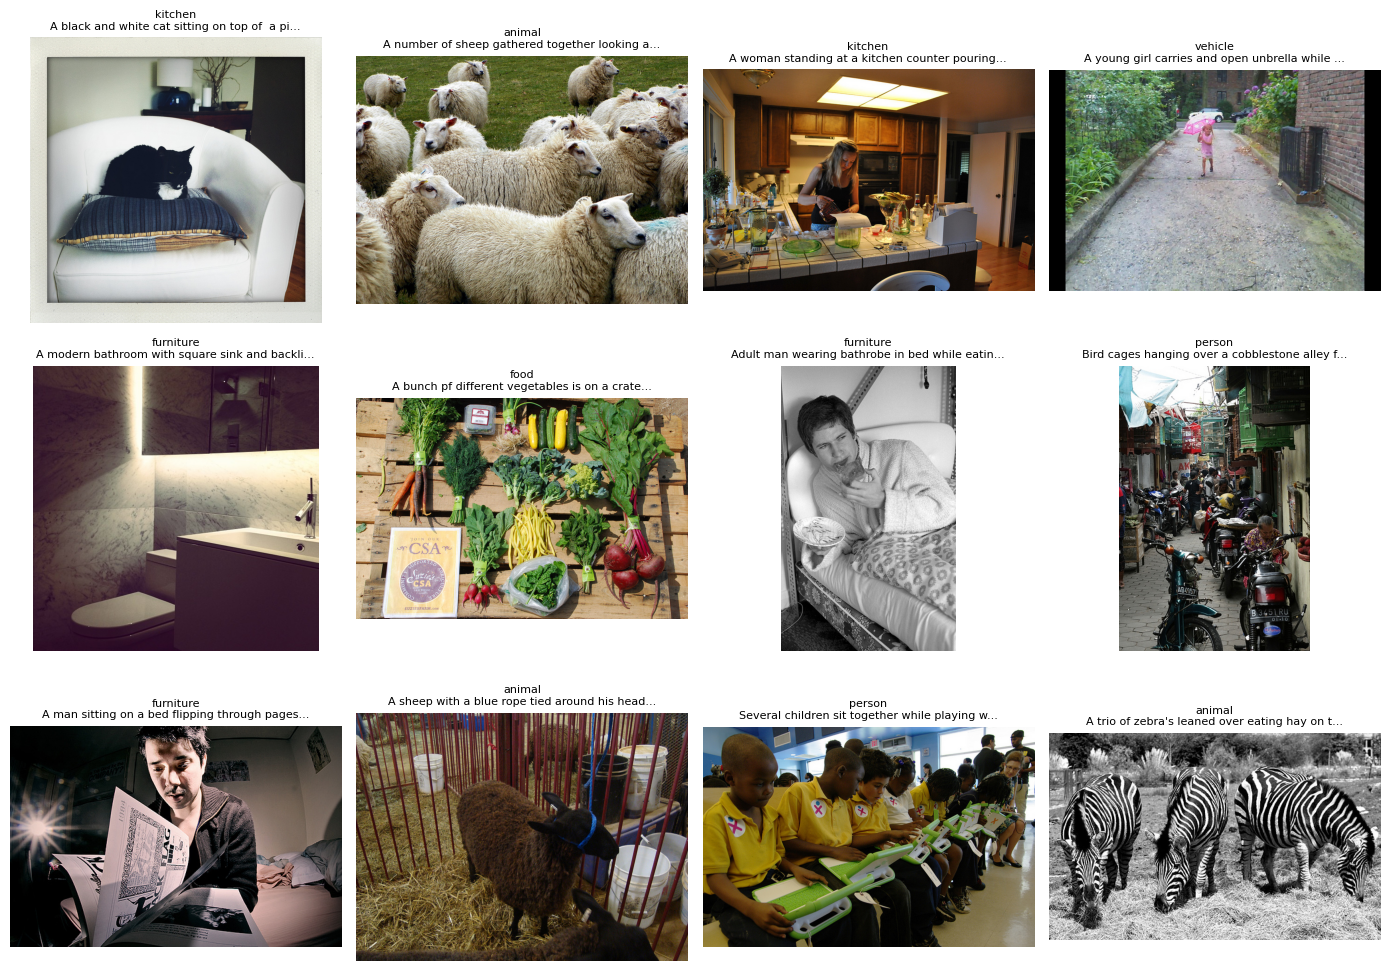

In [8]:
plt.figure(figsize=(10,4))
sns.countplot(data=train_df, y='label_raw', order=train_df['label_raw'].value_counts().index)
plt.title('Train class distribution')
plt.tight_layout()
plt.show()

for part in [train_df, val_df, test_df]:
    part['text_len'] = part['text'].str.split().apply(len)

plt.figure(figsize=(8,4))
sns.histplot(train_df['text_len'], bins=40, kde=True)
plt.title('Caption length distribution (train)')
plt.tight_layout()
plt.show()

sample_vis = train_df.sample(n=min(12, len(train_df)), random_state=42).reset_index(drop=True)
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()
for i, ax in enumerate(axes):
    if i >= len(sample_vis):
        ax.axis('off')
        continue
    row = sample_vis.iloc[i]
    img = Image.open(row['image_path']).convert('RGB')
    ax.imshow(img)
    ax.set_title(f"{row['label_raw']}\n{row['text'][:45]}...", fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [9]:
def compute_metrics(y_true, y_pred):
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro')),
        'weighted_f1': float(f1_score(y_true, y_pred, average='weighted')),
    }

def plot_cm(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Pred')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

def softmax_np(x):
    x = x - np.max(x, axis=1, keepdims=True)
    ex = np.exp(x)
    return ex / np.sum(ex, axis=1, keepdims=True)

def ece_score(y_true, prob, n_bins=15):
    conf = prob.max(axis=1)
    pred = prob.argmax(axis=1)
    acc = (pred == y_true).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins+1)
    ece = 0.0
    xs, ys = [], []
    for i in range(n_bins):
        m = (conf > bins[i]) & (conf <= bins[i+1])
        if m.sum() == 0:
            continue
        bin_acc = acc[m].mean()
        bin_conf = conf[m].mean()
        ece += (m.sum()/len(y_true)) * abs(bin_acc - bin_conf)
        xs.append(bin_conf)
        ys.append(bin_acc)
    return float(ece), xs, ys

In [10]:
clip_ckpt = 'openai/clip-vit-base-patch32'
clip_model = CLIPModel.from_pretrained(clip_ckpt).to(DEVICE).eval()
clip_tokenizer = AutoTokenizer.from_pretrained(clip_ckpt)
clip_image_processor = AutoImageProcessor.from_pretrained(clip_ckpt, use_fast=False)

def clip_encode_batch(imgs=None, txts=None):
    out = {}
    if imgs is not None:
        ii = clip_image_processor(images=imgs, return_tensors='pt')
        out.update(ii)
    if txts is not None:
        ti = clip_tokenizer(txts, return_tensors='pt', padding=True, truncation=True)
        out.update(ti)
    return out


def as_feature_tensor(x):
    if torch.is_tensor(x):
        t = x
    elif hasattr(x, 'image_embeds') and getattr(x, 'image_embeds') is not None:
        t = getattr(x, 'image_embeds')
    elif hasattr(x, 'text_embeds') and getattr(x, 'text_embeds') is not None:
        t = getattr(x, 'text_embeds')
    elif hasattr(x, 'pooler_output') and getattr(x, 'pooler_output') is not None:
        t = getattr(x, 'pooler_output')
    elif hasattr(x, 'last_hidden_state') and getattr(x, 'last_hidden_state') is not None:
        t = getattr(x, 'last_hidden_state')
    elif isinstance(x, dict):
        for key in ['image_embeds', 'text_embeds', 'pooler_output', 'last_hidden_state']:
            if key in x and x[key] is not None:
                t = x[key]
                break
        else:
            raise TypeError(f'Cannot extract feature tensor from dict keys: {list(x.keys())}')
    else:
        raise TypeError(f'Unsupported feature output type: {type(x)}')

    if t.ndim == 3:
        t = t[:, 0, :]
    return t


class MMDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return Image.open(row['image_path']).convert('RGB'), str(row['text']), int(row['label'])


def collate_mm(batch):
    imgs, txts, ys = zip(*batch)
    return list(imgs), list(txts), torch.tensor(ys, dtype=torch.long)


@torch.no_grad()
def encode_mm(df_part):
    loader = DataLoader(
        MMDataset(df_part),
        batch_size=CFG['batch_size_mm'],
        shuffle=False,
        num_workers=CFG['num_workers'],
        collate_fn=collate_mm,
    )
    all_img, all_txt, all_y = [], [], []
    for imgs, txts, ys in tqdm(loader, desc='CLIP encode', leave=False):
        inp_img = clip_encode_batch(imgs=imgs)
        inp_img = {k: v.to(DEVICE) for k, v in inp_img.items()}
        img_f = as_feature_tensor(clip_model.get_image_features(**inp_img))

        inp_txt = clip_encode_batch(txts=txts)
        inp_txt = {k: v.to(DEVICE) for k, v in inp_txt.items()}
        txt_f = as_feature_tensor(clip_model.get_text_features(**inp_txt))

        img_f = img_f / img_f.norm(dim=-1, keepdim=True)
        txt_f = txt_f / txt_f.norm(dim=-1, keepdim=True)

        all_img.append(img_f.cpu().numpy())
        all_txt.append(txt_f.cpu().numpy())
        all_y.append(ys.numpy())

    all_img = np.concatenate(all_img)
    all_txt = np.concatenate(all_txt)
    all_y = np.concatenate(all_y)
    return all_img, all_txt, all_y


def safe_l2_normalize(x, eps=1e-12):
    n = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.clip(n, eps, None)


def fuse_feats(img_f, txt_f, alpha=0.5):
    x = float(alpha) * img_f + (1.0 - float(alpha)) * txt_f
    return safe_l2_normalize(x)


cache_cfg = {
    'clip_ckpt': clip_ckpt,
    'seed': CFG['seed'],
    'batch_size_mm': CFG['batch_size_mm'],
    'num_classes': int(len(le.classes_)),
    'train_size': int(len(train_df)),
    'val_size': int(len(val_df)),
    'test_size': int(len(test_df)),
}
split_ids = np.concatenate([
    train_df['image_id'].to_numpy(np.int64),
    val_df['image_id'].to_numpy(np.int64),
    test_df['image_id'].to_numpy(np.int64),
])
cfg_hash = hashlib.md5(json.dumps(cache_cfg, sort_keys=True).encode('utf-8')).hexdigest()[:10]
split_hash = hashlib.md5(split_ids.tobytes()).hexdigest()[:12]
emb_cache = WORK_DIR / f'coco_clip_embeddings_{cfg_hash}_{split_hash}.npz'

if emb_cache.exists():
    cache = np.load(emb_cache)
    img_train_f = cache['img_train_f']
    txt_train_f = cache['txt_train_f']
    y_train = cache['y_train']
    img_val_f = cache['img_val_f']
    txt_val_f = cache['txt_val_f']
    y_val = cache['y_val']
    img_test_f = cache['img_test_f']
    txt_test_f = cache['txt_test_f']
    y_test = cache['y_test']

    expected = (len(train_df), len(val_df), len(test_df))
    actual = (len(y_train), len(y_val), len(y_test))
    if expected != actual:
        raise ValueError(f'Embedding cache shape mismatch: expected {expected}, got {actual}')

    print('Loaded embedding cache:', emb_cache)
else:
    img_train_f, txt_train_f, y_train = encode_mm(train_df)
    img_val_f, txt_val_f, y_val = encode_mm(val_df)
    img_test_f, txt_test_f, y_test = encode_mm(test_df)

    np.savez_compressed(
        emb_cache,
        img_train_f=img_train_f,
        txt_train_f=txt_train_f,
        y_train=y_train,
        img_val_f=img_val_f,
        txt_val_f=txt_val_f,
        y_val=y_val,
        img_test_f=img_test_f,
        txt_test_f=txt_test_f,
        y_test=y_test,
    )
    print('Saved embedding cache:', emb_cache)

# Base fused features (alpha=0.5) for generic analyses.
X_train = fuse_feats(img_train_f, txt_train_f, alpha=0.5)
X_val = fuse_feats(img_val_f, txt_val_f, alpha=0.5)
X_test = fuse_feats(img_test_f, txt_test_f, alpha=0.5)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

Loaded embedding cache: /content/drive/MyDrive/Deep Learning/data/multimodal_data/work/coco_clip_embeddings_b6df83c3dc_3934c8584c34.npz


Total samples: 5402
Unique image_id: 5402
Unique captions: 5396
Duplicate image_id: 0
Duplicate caption text: 6
Duplicate (image_id, text): 0


,split,n_samples,n_classes,unique_images,unique_captions,text_len_mean,text_len_median,text_len_p95
0,test,811,8,811,811,12.775586,12.0,18.0
1,train,3781,8,3781,3776,12.835493,12.0,18.0
2,val,810,8,810,810,12.912346,12.0,18.0


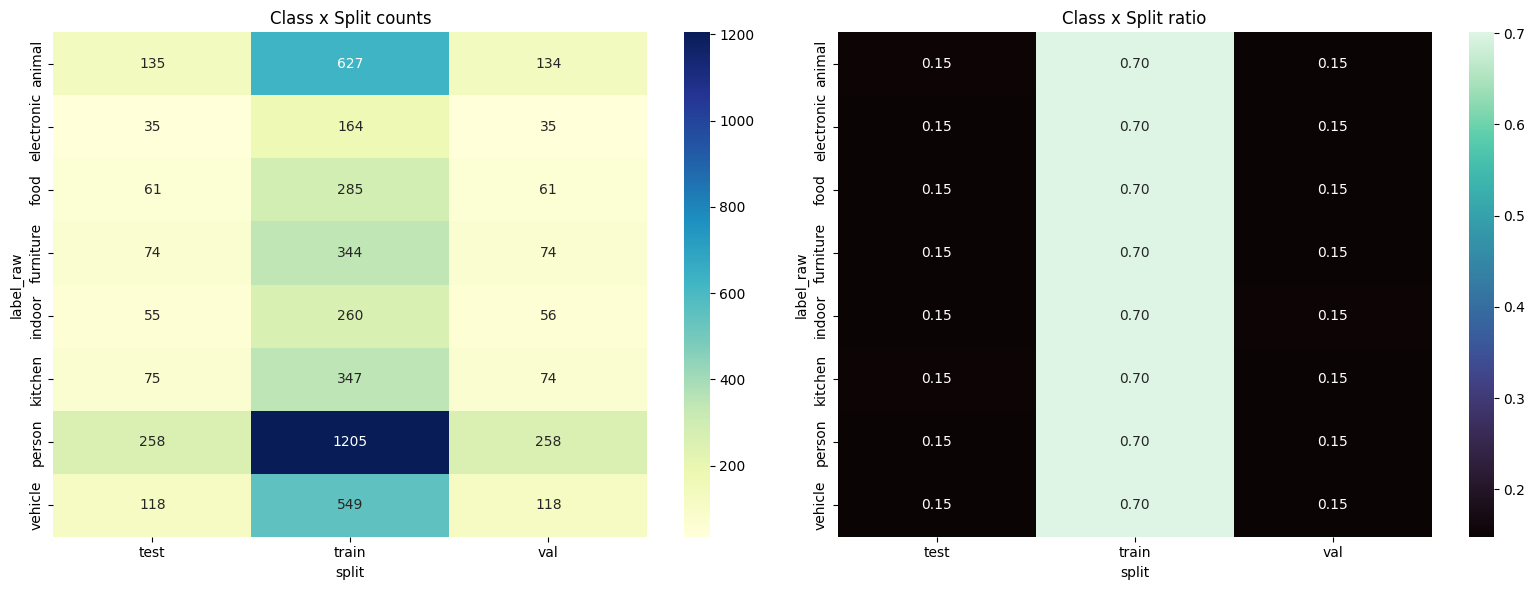

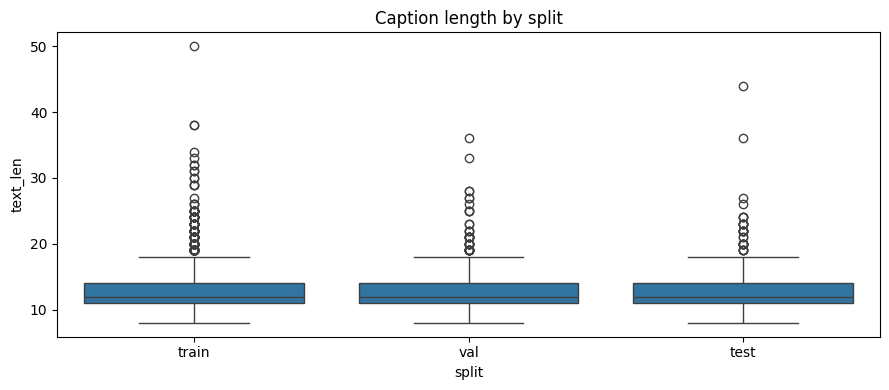

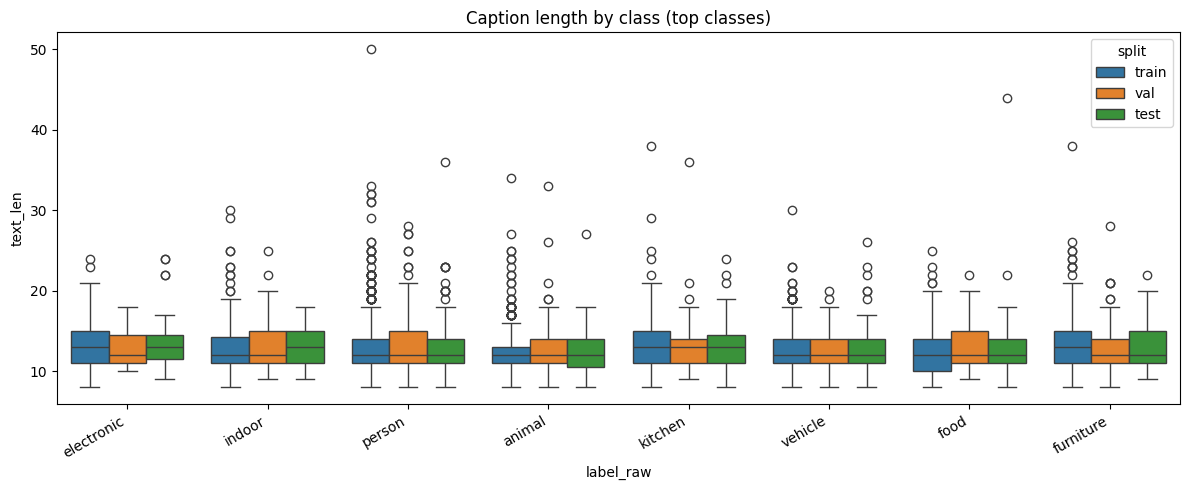

In [11]:
# EDA chi tiet 1: data quality + split/class overview
for part in [train_df, val_df, test_df]:
    if 'text_len' not in part.columns:
        part['text_len'] = part['text'].str.split().apply(len)

eda_df = pd.concat([
    train_df.assign(split='train'),
    val_df.assign(split='val'),
    test_df.assign(split='test'),
], ignore_index=True)

print('Total samples:', len(eda_df))
print('Unique image_id:', eda_df['image_id'].nunique())
print('Unique captions:', eda_df['text'].nunique())
print('Duplicate image_id:', int(eda_df.duplicated(subset=['image_id']).sum()))
print('Duplicate caption text:', int(eda_df.duplicated(subset=['text']).sum()))
print('Duplicate (image_id, text):', int(eda_df.duplicated(subset=['image_id', 'text']).sum()))

summary = eda_df.groupby('split').agg(
    n_samples=('image_id', 'size'),
    n_classes=('label_raw', 'nunique'),
    unique_images=('image_id', 'nunique'),
    unique_captions=('text', 'nunique'),
    text_len_mean=('text_len', 'mean'),
    text_len_median=('text_len', 'median'),
    text_len_p95=('text_len', lambda s: float(np.percentile(s, 95))),
).reset_index()
display(summary)

class_split_counts = pd.crosstab(eda_df['label_raw'], eda_df['split'])
class_split_ratio = class_split_counts.div(class_split_counts.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(class_split_counts, cmap='YlGnBu', annot=True, fmt='d', ax=axes[0])
axes[0].set_title('Class x Split counts')
axes[0].set_xlabel('split')
axes[0].set_ylabel('label_raw')

sns.heatmap(class_split_ratio, cmap='mako', annot=True, fmt='.2f', ax=axes[1])
axes[1].set_title('Class x Split ratio')
axes[1].set_xlabel('split')
axes[1].set_ylabel('label_raw')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
sns.boxplot(data=eda_df, x='split', y='text_len')
plt.title('Caption length by split')
plt.tight_layout()
plt.show()

top_classes = eda_df['label_raw'].value_counts().head(8).index
plt.figure(figsize=(12, 5))
sns.boxplot(data=eda_df[eda_df['label_raw'].isin(top_classes)], x='label_raw', y='text_len', hue='split')
plt.xticks(rotation=30, ha='right')
plt.title('Caption length by class (top classes)')
plt.tight_layout()
plt.show()


,token,count
0,man,626
1,sitting,595
2,two,508
3,standing,495
4,white,446
5,people,429
6,table,330
7,woman,323
8,holding,303
9,large,295


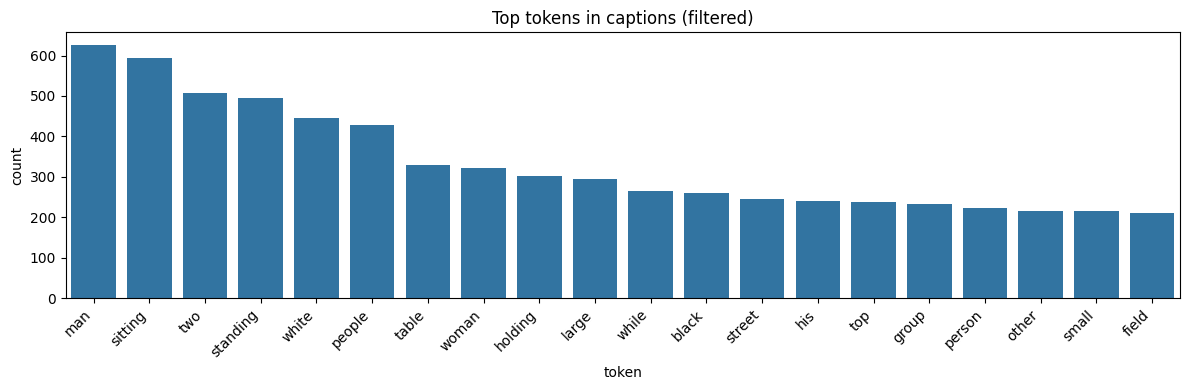

,label_raw,token,count
0,person,man,367
1,person,people,317
2,person,standing,198
3,person,holding,184
4,person,woman,175
5,person,two,152
6,person,his,146
7,person,group,141
8,animal,standing,194
9,animal,two,137


Loaded image meta cache: /content/drive/MyDrive/Deep Learning/data/multimodal_data/work/eda_image_meta_sample.csv
Image meta sample size: 4392


,count,mean,std,min,25%,50%,75%,max
width,4392.0,576.081967,92.510836,200.000,500.00000,640.000000,640.000000,640.000000
height,4392.0,482.614982,97.989937,145.000,426.00000,480.000000,512.000000,640.000000
aspect_ratio,4392.0,1.255902,0.351170,0.448,1.00000,1.333333,1.498829,4.025157
megapixel,4392.0,0.274405,0.052881,0.029,0.27136,0.273600,0.307200,0.409600


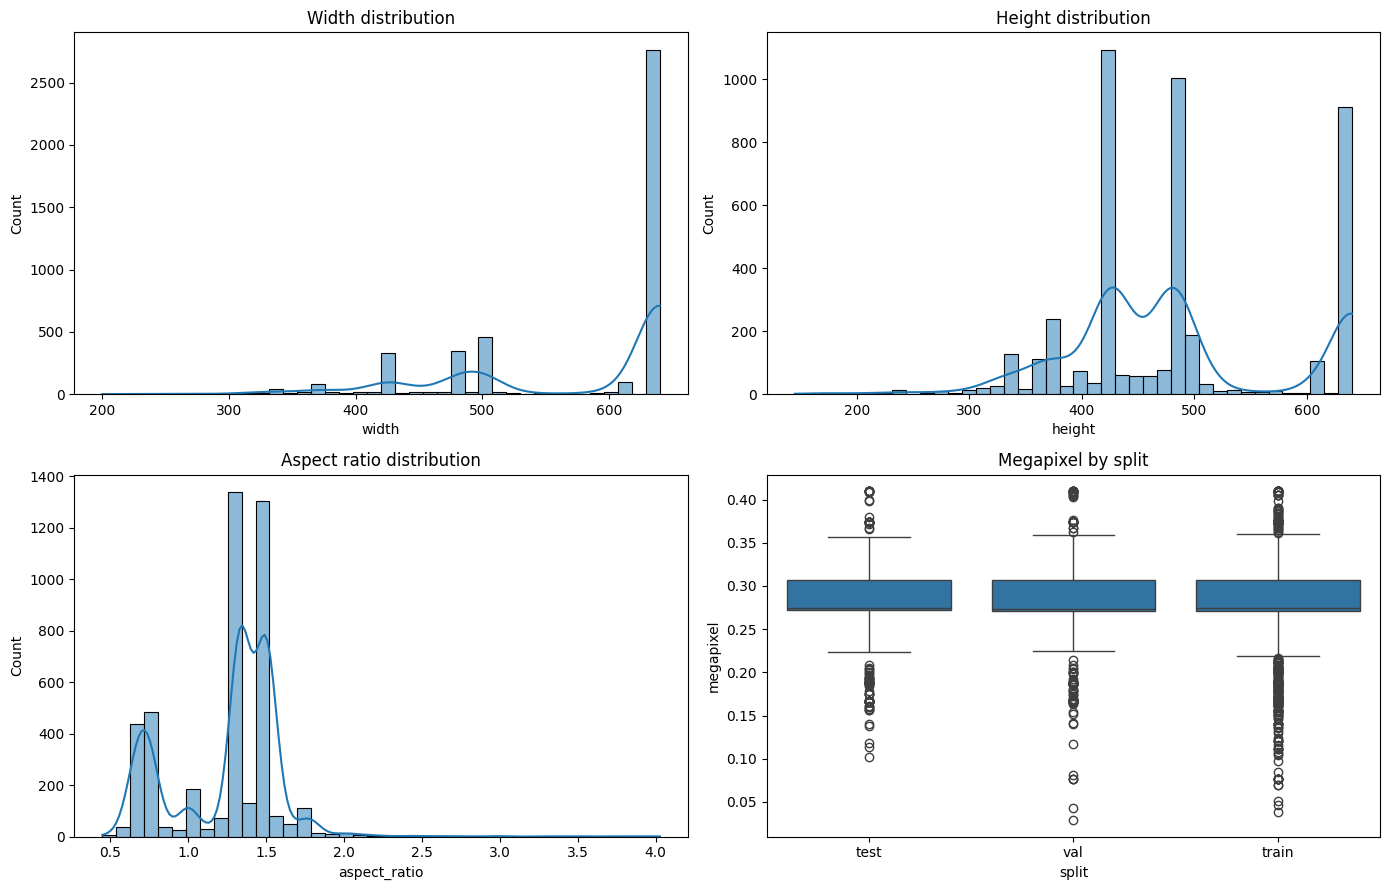

In [12]:
# EDA chi tiet 2: text lexicon + image geometry
import re

if 'eda_df' not in globals():
    for part in [train_df, val_df, test_df]:
        if 'text_len' not in part.columns:
            part['text_len'] = part['text'].str.split().apply(len)
    eda_df = pd.concat([
        train_df.assign(split='train'),
        val_df.assign(split='val'),
        test_df.assign(split='test'),
    ], ignore_index=True)

def tokenize_caption(s):
    return re.findall(r"[a-z]+", str(s).lower())

stop_words = {
    'a','an','the','is','are','of','on','in','at','to','for','with','and','or','this','that',
    'it','its','as','by','from','into','up','down','over','under','near','next','behind','front'
}

all_tokens = []
for t in eda_df['text']:
    toks = [w for w in tokenize_caption(t) if len(w) > 2 and w not in stop_words]
    all_tokens.extend(toks)

tok_counter = Counter(all_tokens)
top_tok_df = pd.DataFrame(tok_counter.most_common(30), columns=['token', 'count'])
display(top_tok_df.head(20))

plt.figure(figsize=(12, 4))
sns.barplot(data=top_tok_df.head(20), x='token', y='count')
plt.xticks(rotation=45, ha='right')
plt.title('Top tokens in captions (filtered)')
plt.tight_layout()
plt.show()

top_cls = eda_df['label_raw'].value_counts().head(4).index.tolist()
rows = []
for cls in top_cls:
    cls_tokens = []
    for t in eda_df.loc[eda_df['label_raw'] == cls, 'text']:
        cls_tokens.extend([w for w in tokenize_caption(t) if len(w) > 2 and w not in stop_words])
    for tok, cnt in Counter(cls_tokens).most_common(8):
        rows.append({'label_raw': cls, 'token': tok, 'count': cnt})

cls_tok_df = pd.DataFrame(rows)
display(cls_tok_df)

meta_cache = WORK_DIR / 'eda_image_meta_sample.csv'
sample_n = min(12000, len(eda_df))
if meta_cache.exists():
    img_meta_df = pd.read_csv(meta_cache)
    print('Loaded image meta cache:', meta_cache)
else:
    sample_df = eda_df.sample(sample_n, random_state=CFG['seed'])[['image_id', 'image_path', 'split', 'label_raw']].copy()
    ws, hs = [], []
    for pth in tqdm(sample_df['image_path'], desc='Read image size'):
        with Image.open(pth) as im:
            w, h = im.size
        ws.append(w)
        hs.append(h)
    sample_df['width'] = ws
    sample_df['height'] = hs
    sample_df['aspect_ratio'] = sample_df['width'] / sample_df['height'].clip(lower=1)
    sample_df['megapixel'] = (sample_df['width'] * sample_df['height']) / 1e6
    img_meta_df = sample_df
    img_meta_df.to_csv(meta_cache, index=False)
    print('Saved image meta cache:', meta_cache)

print('Image meta sample size:', len(img_meta_df))
display(img_meta_df[['width', 'height', 'aspect_ratio', 'megapixel']].describe().T)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.histplot(img_meta_df['width'], bins=40, ax=axes[0, 0], kde=True)
axes[0, 0].set_title('Width distribution')
sns.histplot(img_meta_df['height'], bins=40, ax=axes[0, 1], kde=True)
axes[0, 1].set_title('Height distribution')
sns.histplot(img_meta_df['aspect_ratio'], bins=40, ax=axes[1, 0], kde=True)
axes[1, 0].set_title('Aspect ratio distribution')
sns.boxplot(data=img_meta_df, x='split', y='megapixel', ax=axes[1, 1])
axes[1, 1].set_title('Megapixel by split')
plt.tight_layout()
plt.show()


Alignment stats:


,count,mean,std,min,25%,50%,75%,max
diag_sim,811.0,0.308571,0.032126,0.188707,0.286282,0.307289,0.330949,0.426179
rand_sim,811.0,0.146697,0.041364,0.040806,0.120364,0.145048,0.172836,0.353782


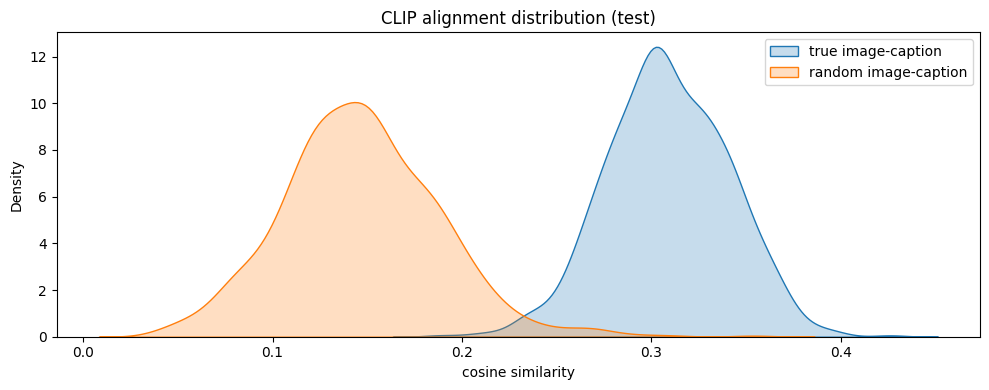

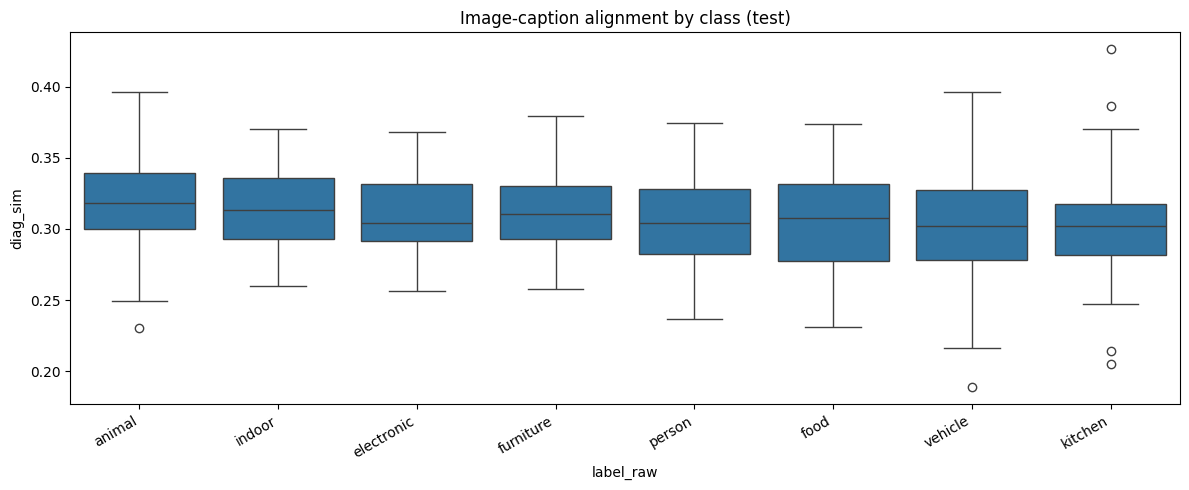

,image_id,label_raw,text,diag_sim
5085,459634,vehicle,A back end of a vehicle with a metal rack and ...,0.188707
3850,313454,kitchen,A man is speaking at a panel in front of a crowd.,0.205400
826,10881,kitchen,A man sitting at a table in a restaurant with ...,0.214466
3484,272136,vehicle,Some type of vehicle with a number on its side...,0.216047
1341,18737,vehicle,a parked red motorcycle a fence and some trees,0.226360
2849,194216,animal,An outdoor area with a large bear and two smal...,0.230139
3375,258793,vehicle,A parking meter sitting next to a street with ...,0.230557
2325,138954,food,A white plate on top of a table topped with fr...,0.230918
3385,259830,vehicle,A scooter and bicycles are parked outside a lo...,0.233430
2354,142472,vehicle,A bunch of pedestrians as well as cars are on ...,0.233832


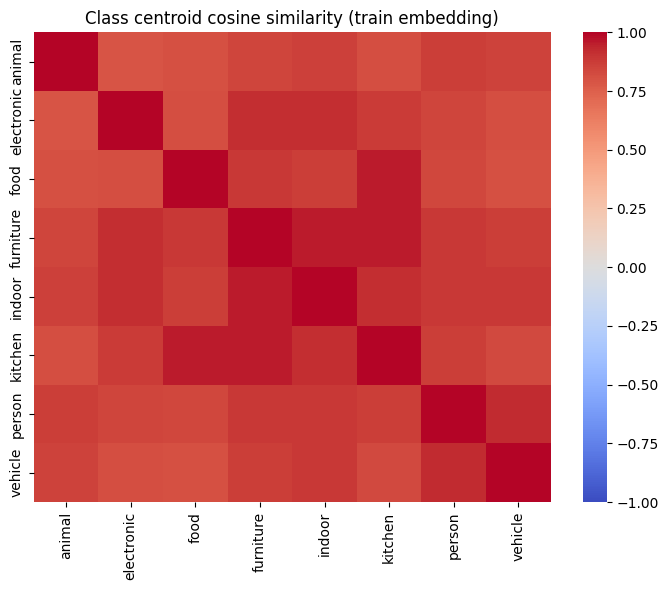

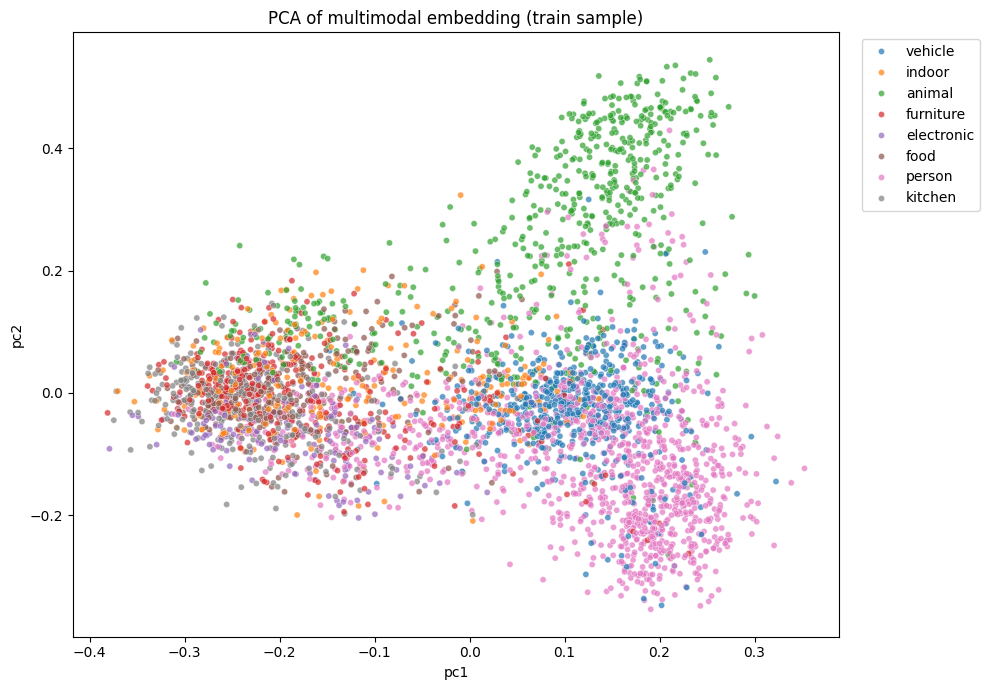

In [13]:
# EDA chi tiet 3: multimodal alignment + separability (dua tren CLIP embeddings)
required_vars = ['img_train_f', 'txt_train_f', 'img_test_f', 'txt_test_f', 'X_train', 'y_train', 'X_test', 'y_test']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'Can run this cell only after embedding cell. Missing: {missing}')

# 1) Alignment score: cosine(image, text) cho dung caption vs random caption
diag_sim = np.sum(img_test_f * txt_test_f, axis=1)
perm = np.random.default_rng(CFG['seed']).permutation(len(txt_test_f))
rand_sim = np.sum(img_test_f * txt_test_f[perm], axis=1)

align_df = pd.DataFrame({
    'diag_sim': diag_sim,
    'rand_sim': rand_sim,
    'label_raw': test_df['label_raw'].to_numpy(),
})
print('Alignment stats:')
display(align_df[['diag_sim', 'rand_sim']].describe().T)

plt.figure(figsize=(10, 4))
sns.kdeplot(align_df['diag_sim'], label='true image-caption', fill=True)
sns.kdeplot(align_df['rand_sim'], label='random image-caption', fill=True)
plt.title('CLIP alignment distribution (test)')
plt.xlabel('cosine similarity')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
order = align_df.groupby('label_raw')['diag_sim'].mean().sort_values(ascending=False).index
sns.boxplot(data=align_df, x='label_raw', y='diag_sim', order=order)
plt.xticks(rotation=30, ha='right')
plt.title('Image-caption alignment by class (test)')
plt.tight_layout()
plt.show()

hard_idx = np.argsort(diag_sim)[:12]
hard_df = test_df.iloc[hard_idx][['image_id', 'label_raw', 'text']].copy()
hard_df['diag_sim'] = diag_sim[hard_idx]
display(hard_df.sort_values('diag_sim'))

# 2) Class separability in embedding space
from sklearn.decomposition import PCA

centroids = []
classes_int = sorted(np.unique(y_train))
for c in classes_int:
    centroids.append(X_train[y_train == c].mean(axis=0))
centroids = np.stack(centroids)
centroids = centroids / np.clip(np.linalg.norm(centroids, axis=1, keepdims=True), 1e-12, None)
cent_sim = centroids @ centroids.T

plt.figure(figsize=(7, 6))
sns.heatmap(cent_sim, cmap='coolwarm', vmin=-1, vmax=1, xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Class centroid cosine similarity (train embedding)')
plt.tight_layout()
plt.show()

sample_n = min(5000, len(X_train))
sample_idx = np.random.default_rng(CFG['seed']).choice(len(X_train), sample_n, replace=False)
X2 = PCA(n_components=2, random_state=CFG['seed']).fit_transform(X_train[sample_idx])
plot_df = pd.DataFrame({'pc1': X2[:, 0], 'pc2': X2[:, 1], 'label_raw': np.array(le.classes_)[y_train[sample_idx]]})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x='pc1', y='pc2', hue='label_raw', s=20, alpha=0.7)
plt.title('PCA of multimodal embedding (train sample)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


,alpha,val_acc,val_macro_f1
0,0.60,0.604938,0.530671
1,0.65,0.607407,0.530446
2,0.70,0.607407,0.528028
3,0.75,0.607407,0.522943
4,0.80,0.608642,0.521310
5,0.55,0.595062,0.516959
6,0.85,0.606173,0.514689
7,0.90,0.601235,0.509243
8,0.95,0.600000,0.508324
9,0.50,0.582716,0.505204


VAPF best alpha on val: 0.60 (val Macro-F1=0.5307)
Zero-shot (multi-prompt + VAPF): {'accuracy': 0.6066584463625154, 'macro_f1': 0.5308298505654678, 'weighted_f1': 0.5952187214688249}


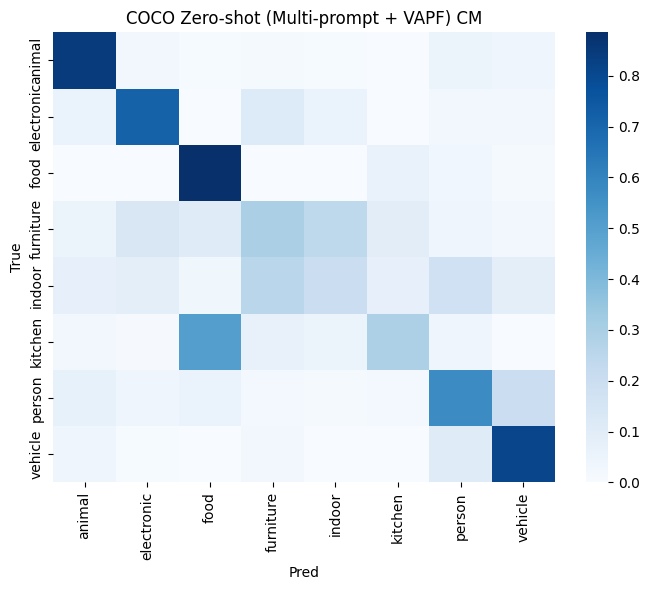

,alpha,C,val_acc,val_macro_f1
0,0.80,5.0,0.717325,0.705211
1,0.75,5.0,0.717325,0.702601
2,0.70,5.0,0.715805,0.700938
3,0.75,10.0,0.709726,0.697708
4,0.55,10.0,0.709726,0.696240
5,0.55,2.0,0.717325,0.696172
6,0.80,2.0,0.717325,0.695845
7,0.85,5.0,0.708207,0.695693
8,0.80,10.0,0.705167,0.694795
9,0.60,2.0,0.718845,0.694638


Few-shot best config by val Macro-F1 -> alpha=0.8, C=5.0, val_macro_f1=0.7052
Few-shot LR (tuned): {'accuracy': 0.6621454993834772, 'macro_f1': 0.6434127144204524, 'weighted_f1': 0.6590090955096692}


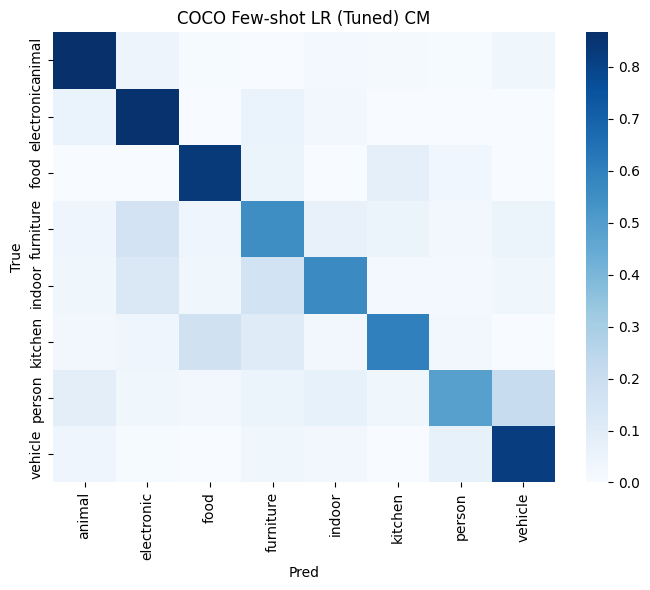

Few-shot SVM: {'accuracy': 0.623921085080148, 'macro_f1': 0.6235337025851977, 'weighted_f1': 0.6200163177195974}
Few-shot MLP: {'accuracy': 0.6263871763255241, 'macro_f1': 0.6097500262936951, 'weighted_f1': 0.6251433777116842}
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


Loaded CNN embedding cache: /content/drive/MyDrive/Deep Learning/data/multimodal_data/work/coco_cnn_fewshot_1b7abcda943e.npz
Few-shot CNN(ResNet18)+LR: {'accuracy': 0.5351418002466092, 'macro_f1': 0.5061960146857238, 'weighted_f1': 0.5358897480656878}


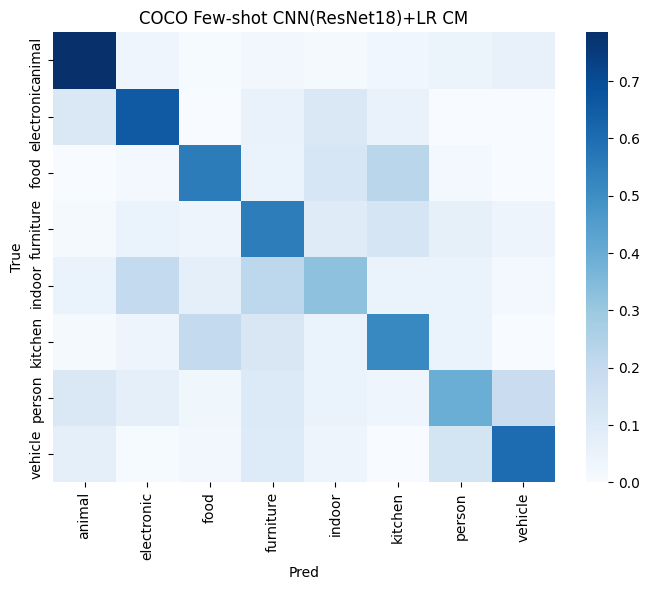

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP-head train ep1:   0%|          | 0/16 [00:00<?, ?it/s]

CLIP-head eval:   0%|          | 0/102 [00:00<?, ?it/s]

CLIP-head epoch 1: val_acc=0.2309, val_macro_f1=0.2039


...

CLIP-head train ep10:   0%|          | 0/16 [00:00<?, ?it/s]

CLIP-head eval:   0%|          | 0/102 [00:00<?, ?it/s]

CLIP-head epoch 10: val_acc=0.6753, val_macro_f1=0.6442


CLIP-head eval:   0%|          | 0/102 [00:00<?, ?it/s]

Few-shot CLIP-head fine-tune: {'accuracy': 0.6424167694204685, 'macro_f1': 0.6109999477646769, 'weighted_f1': 0.6377579875191113}


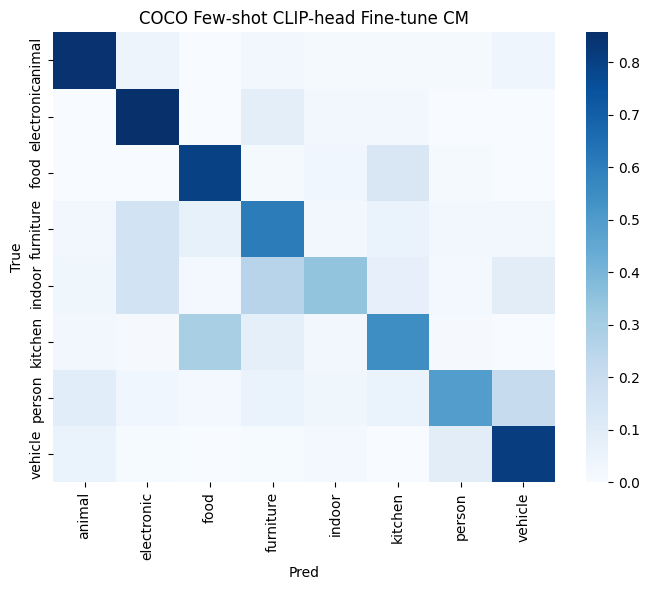

In [14]:
# Zero-shot: multi-prompt + VAPF tuning on validation
class_names = list(le.classes_)

# prompt_templates = [
#     'a photo mainly about {}',
#     'this image and caption are about {}',
#     'an example of {} scene',
#     'a realistic photo of {}',
#     'a social media photo showing {}',
#     'a daily life scene related to {}',
#     'an image where the main concept is {}',
#     'a picture focused on {}',
# ]
prompt_templates = [
    'a photo of {}',
    'a realistic image of {}',
    'a scene featuring {}',
    'an everyday scene related to {}',
    'a natural photo showing {}',
    'an image where the main concept is {}',
    'this image and caption are about {}',
    'a picture focused on {}',
]

# CLASS_TEXT_MAP = {
#     'person': 'people and human activities',
#     'animal': 'animals or pets',
#     'sports': 'sports activities',
#     'vehicle': 'transportation and vehicles',
#     'outdoor': 'nature and outdoor scenery',
#     'indoor': 'indoor room environment',
#     'kitchen': 'kitchen and cooking context',
#     'food': 'food and meal scenes',
# }

CLASS_TEXT_MAP = {
    'person': 'people and human activities',
    'animal': 'animals or pets',
    'vehicle': 'transportation and vehicles',
    'kitchen': 'kitchen and cooking context',
    'furniture': 'furniture and household items',
    'food': 'food and meal scenes',
    'indoor': 'indoor room environment',
    'electronic': 'electronic devices and gadgets',
}

def normalize_class_text(c):
    base = str(c).strip().lower()
    return CLASS_TEXT_MAP.get(base, base.replace('_', ' '))


def build_class_prompt_texts(classes):
    all_texts = []
    for c in classes:
        c_text = normalize_class_text(c)
        for t in prompt_templates:
            all_texts.append(t.format(c_text))
    return all_texts


zs_texts = build_class_prompt_texts(class_names)
with torch.no_grad():
    inp = clip_encode_batch(txts=zs_texts)
    inp = {k: v.to(DEVICE) for k, v in inp.items()}
    txt_feat = as_feature_tensor(clip_model.get_text_features(**inp))
    txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)
    txt_feat = txt_feat.cpu().numpy()

n_temp = len(prompt_templates)
class_proto = []
for i in range(len(class_names)):
    chunk = txt_feat[i * n_temp:(i + 1) * n_temp]
    c = chunk.mean(axis=0)
    c = c / (np.linalg.norm(c) + 1e-12)
    class_proto.append(c)
class_proto = np.vstack(class_proto)

vapf_alpha_grid = np.round(np.linspace(0.0, 1.0, 21), 2).tolist()
vapf_rows = []
vapf_best_alpha, vapf_best_f1 = None, -1.0
for alpha_try in vapf_alpha_grid:
    X_val_zs = fuse_feats(img_val_f, txt_val_f, alpha=float(alpha_try))
    logits_val = X_val_zs @ class_proto.T
    pred_val = np.argmax(logits_val, axis=1)
    f1_val = f1_score(y_val, pred_val, average='macro')
    acc_val = accuracy_score(y_val, pred_val)
    vapf_rows.append({'alpha': float(alpha_try), 'val_acc': float(acc_val), 'val_macro_f1': float(f1_val)})
    if f1_val > vapf_best_f1:
        vapf_best_f1 = float(f1_val)
        vapf_best_alpha = float(alpha_try)

vapf_df = pd.DataFrame(vapf_rows).sort_values('val_macro_f1', ascending=False).reset_index(drop=True)
display(vapf_df.head(10))
print(f'VAPF best alpha on val: {vapf_best_alpha:.2f} (val Macro-F1={vapf_best_f1:.4f})')

X_test_zs = fuse_feats(img_test_f, txt_test_f, alpha=vapf_best_alpha)
X_val_zs = fuse_feats(img_val_f, txt_val_f, alpha=vapf_best_alpha)

zs_logits = X_test_zs @ class_proto.T
zs_prob = softmax_np(zs_logits)
zs_pred = np.argmax(zs_logits, axis=1)

zs_logits_val = X_val_zs @ class_proto.T
zs_prob_val = softmax_np(zs_logits_val)

zs_metrics = compute_metrics(y_test, zs_pred)
print('Zero-shot (multi-prompt + VAPF):', zs_metrics)
plot_cm(y_test, zs_pred, class_names, 'COCO Zero-shot (Multi-prompt + VAPF) CM')

# Few-shot sample set
k = CFG['few_shot_k_per_class']
few_idx = []
rng = np.random.default_rng(CFG['seed'])
for c in sorted(np.unique(y_train)):
    idx = np.where(y_train == c)[0]
    idx = idx.copy()
    rng.shuffle(idx)
    few_idx.extend(idx[:k].tolist())
few_idx = np.array(few_idx)

y_few = y_train[few_idx]
few_train_df = train_df.reset_index(drop=True).iloc[few_idx].copy()
few_val_df = val_df.reset_index(drop=True).copy()
few_test_df = test_df.reset_index(drop=True).copy()


def make_balanced_idx(y, max_per_class=120, seed=42):
    rng_local = np.random.default_rng(seed)
    out = []
    for c in sorted(np.unique(y)):
        idx = np.where(y == c)[0].copy()
        rng_local.shuffle(idx)
        out.extend(idx[:min(max_per_class, len(idx))].tolist())
    return np.array(sorted(out), dtype=np.int64)


val_tune_idx = make_balanced_idx(y_val, max_per_class=120, seed=CFG['seed'])
y_val_tune = y_val[val_tune_idx]

few_alpha_grid = np.round(np.linspace(0.10, 0.90, 17), 2).tolist()
few_c_grid = [0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]


def make_lr(c_val):
    kwargs = dict(max_iter=6000, C=float(c_val), class_weight='balanced', solver='lbfgs', n_jobs=-1)
    return LogisticRegression(**kwargs)


few_rows = []
few_best = {'f1': -1.0, 'alpha': None, 'C': None, 'clf': None}

for alpha_try in few_alpha_grid:
    X_few_alpha = fuse_feats(img_train_f[few_idx], txt_train_f[few_idx], alpha=alpha_try)
    X_val_alpha = fuse_feats(img_val_f[val_tune_idx], txt_val_f[val_tune_idx], alpha=alpha_try)

    for c_try in few_c_grid:
        clf_try = make_lr(c_try)
        clf_try.fit(X_few_alpha, y_few)
        pred_val = clf_try.predict(X_val_alpha)
        f1_val = f1_score(y_val_tune, pred_val, average='macro')
        acc_val = accuracy_score(y_val_tune, pred_val)

        few_rows.append({
            'alpha': float(alpha_try),
            'C': float(c_try),
            'val_acc': float(acc_val),
            'val_macro_f1': float(f1_val),
        })

        if f1_val > few_best['f1']:
            few_best = {'f1': float(f1_val), 'alpha': float(alpha_try), 'C': float(c_try), 'clf': clf_try}

few_tuning_df = pd.DataFrame(few_rows).sort_values('val_macro_f1', ascending=False).reset_index(drop=True)
display(few_tuning_df.head(12))
print(f"Few-shot best config by val Macro-F1 -> alpha={few_best['alpha']}, C={few_best['C']}, val_macro_f1={few_best['f1']:.4f}")

few_clf = few_best['clf']
X_few = fuse_feats(img_train_f[few_idx], txt_train_f[few_idx], alpha=few_best['alpha'])
X_val_best = fuse_feats(img_val_f, txt_val_f, alpha=few_best['alpha'])
X_test_best = fuse_feats(img_test_f, txt_test_f, alpha=few_best['alpha'])

few_pred = few_clf.predict(X_test_best)
few_prob = few_clf.predict_proba(X_test_best)
few_prob_val = few_clf.predict_proba(X_val_best)
few_metrics = compute_metrics(y_test, few_pred)
print('Few-shot LR (tuned):', few_metrics)
plot_cm(y_test, few_pred, class_names, 'COCO Few-shot LR (Tuned) CM')

# Extra model 1: SVM
svm_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='linear', probability=True, random_state=CFG['seed']))
])
svm_clf.fit(X_few, y_few)
svm_pred = svm_clf.predict(X_test_best)
svm_prob = svm_clf.predict_proba(X_test_best)
svm_metrics = compute_metrics(y_test, svm_pred)
print('Few-shot SVM:', svm_metrics)

# Extra model 2: MLP
mlp_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(
        hidden_layer_sizes=(256,),
        activation='relu',
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=400,
        early_stopping=True,
        random_state=CFG['seed'],
    ))
])
mlp_clf.fit(X_few, y_few)
mlp_pred = mlp_clf.predict(X_test_best)
mlp_prob = mlp_clf.predict_proba(X_test_best)
mlp_metrics = compute_metrics(y_test, mlp_pred)
print('Few-shot MLP:', mlp_metrics)

# Extra model 3: CNN (ResNet18 image-only) + LR
cnn_weights = models.ResNet18_Weights.DEFAULT
cnn_backbone = models.resnet18(weights=cnn_weights)
cnn_backbone.fc = nn.Identity()
cnn_backbone = cnn_backbone.to(DEVICE).eval()
cnn_preprocess = cnn_weights.transforms()


@torch.no_grad()
def encode_cnn_df(df_part, desc='CNN encode'):
    loader = DataLoader(
        MMDataset(df_part),
        batch_size=CFG['batch_size_mm'],
        shuffle=False,
        num_workers=0,
        collate_fn=collate_mm,
    )
    af, ay = [], []
    for imgs, _, ys in tqdm(loader, desc=desc, leave=False):
        x = torch.stack([cnn_preprocess(im) for im in imgs]).to(DEVICE)
        feat = cnn_backbone(x)
        feat = feat / feat.norm(dim=-1, keepdim=True)
        af.append(feat.cpu().numpy())
        ay.append(ys.numpy())

    af = np.concatenate(af)
    ay = np.concatenate(ay)
    X = af / np.clip(np.linalg.norm(af, axis=1, keepdims=True), 1e-12, None)
    return X, ay


cnn_cache_cfg = {
    'cnn_backbone': 'resnet18',
    'seed': CFG['seed'],
    'batch_size_mm': CFG['batch_size_mm'],
    'few_n': int(len(few_train_df)),
    'test_n': int(len(few_test_df)),
}
cnn_ids = np.concatenate([
    few_train_df['image_id'].to_numpy(np.int64),
    few_test_df['image_id'].to_numpy(np.int64),
])
cnn_key = hashlib.md5((json.dumps(cnn_cache_cfg, sort_keys=True) + hashlib.md5(cnn_ids.tobytes()).hexdigest()).encode('utf-8')).hexdigest()[:12]
cnn_cache = WORK_DIR / f'coco_cnn_fewshot_{cnn_key}.npz'

if cnn_cache.exists():
    c = np.load(cnn_cache)
    X_few_cnn = c['X_few_cnn']
    y_few_cnn = c['y_few_cnn']
    X_test_cnn = c['X_test_cnn']
    y_test_cnn = c['y_test_cnn']
    print('Loaded CNN embedding cache:', cnn_cache)
else:
    X_few_cnn, y_few_cnn = encode_cnn_df(few_train_df, desc='CNN encode few-shot')
    X_test_cnn, y_test_cnn = encode_cnn_df(few_test_df, desc='CNN encode test')
    np.savez_compressed(
        cnn_cache,
        X_few_cnn=X_few_cnn,
        y_few_cnn=y_few_cnn,
        X_test_cnn=X_test_cnn,
        y_test_cnn=y_test_cnn,
    )
    print('Saved CNN embedding cache:', cnn_cache)

cnn_few_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=5000))
])
cnn_few_clf.fit(X_few_cnn, y_few_cnn)
cnn_few_pred = cnn_few_clf.predict(X_test_cnn)
cnn_few_prob = cnn_few_clf.predict_proba(X_test_cnn)
cnn_few_metrics = compute_metrics(y_test_cnn, cnn_few_pred)
print('Few-shot CNN(ResNet18)+LR:', cnn_few_metrics)
plot_cm(y_test_cnn, cnn_few_pred, class_names, 'COCO Few-shot CNN(ResNet18)+LR CM')


# Few-shot fine-tune CLIP head
class MMRawDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        return img, str(row['text']), int(row['label'])


def collate_raw(batch):
    imgs, txts, ys = zip(*batch)
    return list(imgs), list(txts), torch.tensor(ys, dtype=torch.long)


class CLIPHeadClassifier(nn.Module):
    def __init__(self, clip_backbone, num_classes, train_proj=True):
        super().__init__()
        self.clip = clip_backbone
        for p in self.clip.parameters():
            p.requires_grad = False
        if train_proj:
            for p in self.clip.visual_projection.parameters():
                p.requires_grad = True
            for p in self.clip.text_projection.parameters():
                p.requires_grad = True
        dim = self.clip.config.projection_dim
        self.dropout = nn.Dropout(0.2)
        self.classifier = nn.Linear(dim * 2, num_classes)

    def forward(self, pixel_values, input_ids, attention_mask):
        img = as_feature_tensor(self.clip.get_image_features(pixel_values=pixel_values))
        txt = as_feature_tensor(self.clip.get_text_features(input_ids=input_ids, attention_mask=attention_mask))
        img = img / img.norm(dim=-1, keepdim=True)
        txt = txt / txt.norm(dim=-1, keepdim=True)
        feat = torch.cat([img, txt], dim=1)
        return self.classifier(self.dropout(feat))


@torch.no_grad()
def eval_clip_head(model, loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    for imgs, txts, ys in tqdm(loader, desc='CLIP-head eval', leave=False):
        inp = clip_encode_batch(imgs=imgs, txts=txts)
        inp = {k: v.to(DEVICE) for k, v in inp.items()}
        logits = model(
            pixel_values=inp['pixel_values'],
            input_ids=inp['input_ids'],
            attention_mask=inp['attention_mask'],
        )
        prob = torch.softmax(logits, dim=1).cpu().numpy()
        pred = np.argmax(prob, axis=1)
        y_prob.append(prob)
        y_pred.extend(pred.tolist())
        y_true.extend(ys.numpy().tolist())
    y_prob = np.concatenate(y_prob, axis=0)
    return compute_metrics(y_true, y_pred), np.array(y_true), np.array(y_pred), y_prob


def train_clip_head_fewshot(few_train_df, val_df, test_df, num_classes):
    clip_ft = CLIPModel.from_pretrained(clip_ckpt).to(DEVICE)
    model = CLIPHeadClassifier(clip_ft, num_classes=num_classes, train_proj=True).to(DEVICE)
    train_loader = DataLoader(MMRawDataset(few_train_df), batch_size=CFG['clip_head_batch_size'], shuffle=True, num_workers=0, collate_fn=collate_raw)
    val_loader = DataLoader(MMRawDataset(val_df), batch_size=CFG['clip_head_batch_size'], shuffle=False, num_workers=0, collate_fn=collate_raw)
    test_loader = DataLoader(MMRawDataset(test_df), batch_size=CFG['clip_head_batch_size'], shuffle=False, num_workers=0, collate_fn=collate_raw)

    optim = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=CFG['lr_clip_head'])
    crit = nn.CrossEntropyLoss()
    best_f1 = -1
    best_state = None

    for ep in range(1, CFG['clip_head_epochs'] + 1):
        model.train()
        model.clip.eval()
        for imgs, txts, ys in tqdm(train_loader, desc=f'CLIP-head train ep{ep}', leave=False):
            inp = clip_encode_batch(imgs=imgs, txts=txts)
            inp = {k: v.to(DEVICE) for k, v in inp.items()}
            ys = ys.to(DEVICE)
            logits = model(
                pixel_values=inp['pixel_values'],
                input_ids=inp['input_ids'],
                attention_mask=inp['attention_mask'],
            )
            loss = crit(logits, ys)
            optim.zero_grad()
            loss.backward()
            optim.step()

        val_metrics, _, _, _ = eval_clip_head(model, val_loader)
        print(f"CLIP-head epoch {ep}: val_acc={val_metrics['accuracy']:.4f}, val_macro_f1={val_metrics['macro_f1']:.4f}")
        if val_metrics['macro_f1'] > best_f1:
            best_f1 = val_metrics['macro_f1']
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics, y_true, y_pred, y_prob = eval_clip_head(model, test_loader)
    return model, test_metrics, y_true, y_pred, y_prob


clip_head_model, clip_head_metrics, y_true_clip_head, clip_head_pred, clip_head_prob = train_clip_head_fewshot(
    few_train_df=few_train_df,
    val_df=few_val_df,
    test_df=few_test_df,
    num_classes=len(class_names),
)
print('Few-shot CLIP-head fine-tune:', clip_head_metrics)
plot_cm(y_true_clip_head, clip_head_pred, class_names, 'COCO Few-shot CLIP-head Fine-tune CM')


{'ece_zero_shot': 0.4754352342296028, 'ece_few_shot': 0.22424774205814066, 'ece_cnn_few_shot': 0.1758849949167725}


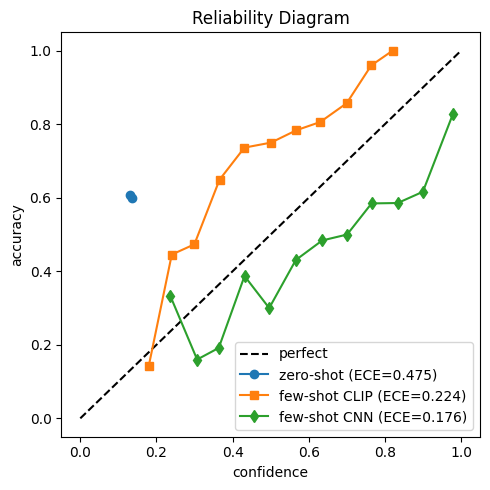

Few-shot misclassified: 274


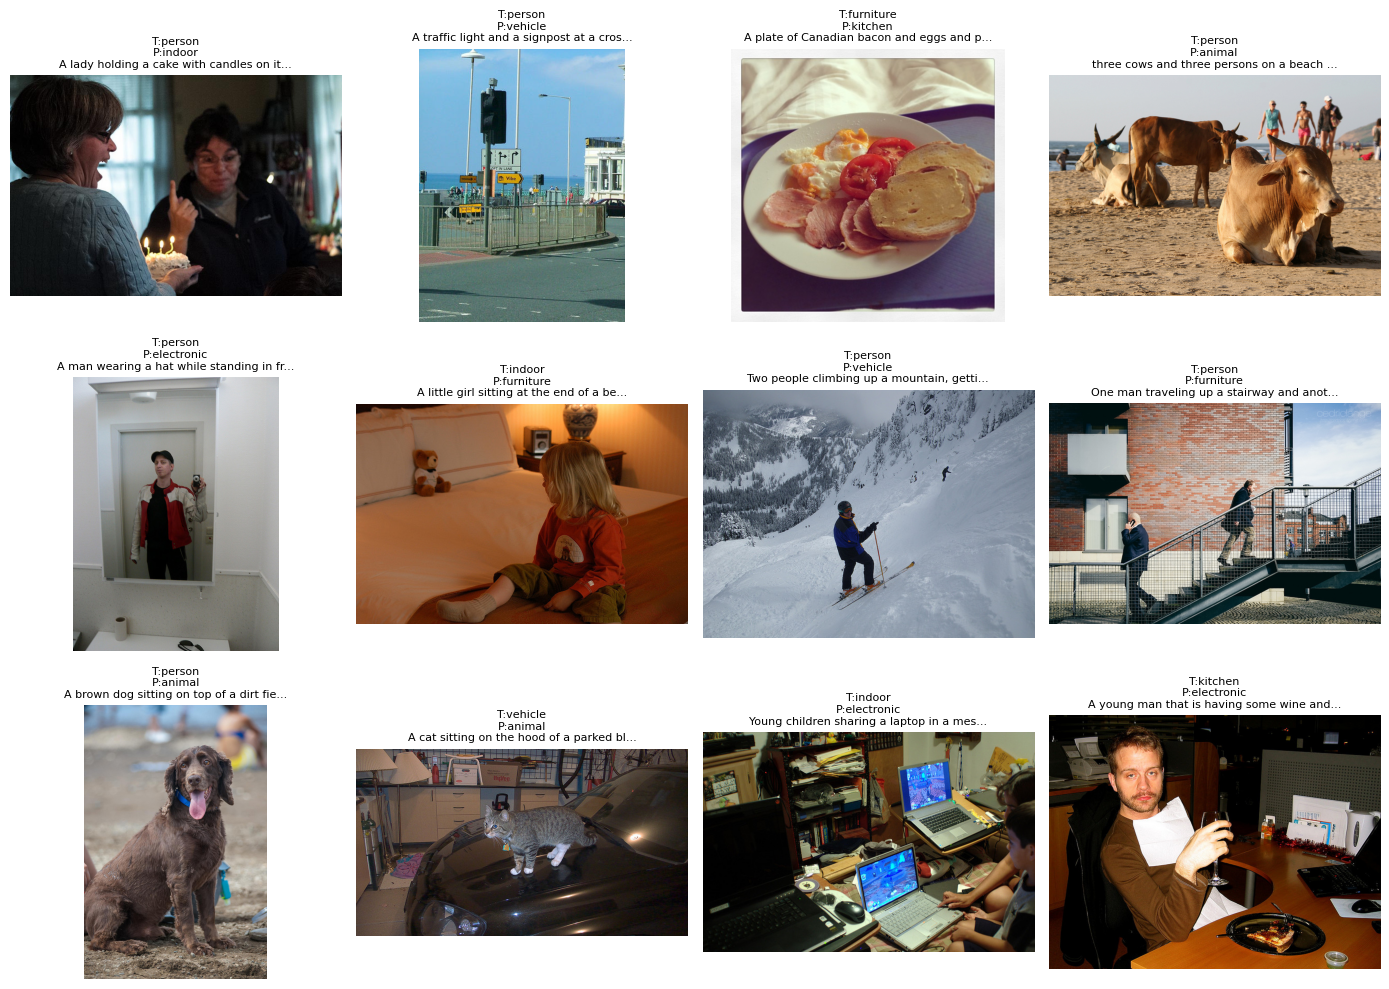

{'ensemble_alpha': 0.1, 'ensemble_val_macro_f1': 0.6801175907417203, 'accuracy': 0.6720098643649816, 'macro_f1': 0.6502804056929934, 'weighted_f1': 0.6675584476445271}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Robust encode:   0%|          | 0/9 [00:00<?, ?it/s]

{'robust_zero_shot': {'accuracy': 0.5807644882860666, 'macro_f1': 0.507896027447638, 'weighted_f1': 0.5662546242703753}, 'robust_few_shot': {'accuracy': 0.6387176325524044, 'macro_f1': 0.6286629270809069, 'weighted_f1': 0.6378768557970209}}
{'latency_ms_per_sample_zero_shot': 0.0002494217015153102, 'latency_ms_per_sample_few_shot': 0.011295181257721956, 'clip_params_million': 151.277313}


In [15]:
# Calibration
ece_zs, xz, yz = ece_score(y_test, zs_prob)
ece_few, xf, yf = ece_score(y_test, few_prob)
ece_cnn, xc, yc = ece_score(y_test, cnn_few_prob)
print({
    'ece_zero_shot': ece_zs,
    'ece_few_shot': ece_few,
    'ece_cnn_few_shot': ece_cnn,
})

plt.figure(figsize=(5,5))
plt.plot([0,1],[0,1],'k--',label='perfect')
if len(xz) > 0: plt.plot(xz, yz, 'o-', label=f'zero-shot (ECE={ece_zs:.3f})')
if len(xf) > 0: plt.plot(xf, yf, 's-', label=f'few-shot CLIP (ECE={ece_few:.3f})')
if len(xc) > 0: plt.plot(xc, yc, 'd-', label=f'few-shot CNN (ECE={ece_cnn:.3f})')
plt.xlabel('confidence')
plt.ylabel('accuracy')
plt.title('Reliability Diagram')
plt.legend()
plt.tight_layout()
plt.show()

# Error analysis
err_idx = np.where(few_pred != y_test)[0]
print('Few-shot misclassified:', len(err_idx))
if len(err_idx) > 0:
    show_n = min(12, len(err_idx))
    pick = np.random.choice(err_idx, size=show_n, replace=False)
    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    axes = axes.flatten()
    for ax_i, idx in enumerate(pick):
        row = test_df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        axes[ax_i].imshow(img)
        t = str(row['text'])[:40].replace('\n', ' ')
        axes[ax_i].set_title(f"T:{id2label[int(y_test[idx])]}\nP:{id2label[int(few_pred[idx])]}\n{t}...", fontsize=8)
        axes[ax_i].axis('off')
    for j in range(show_n, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

# Ensemble
best_alpha, best_mf1 = 0.5, -1
for a in np.linspace(0.0, 1.0, 11):
    p_val = a * few_prob_val + (1-a) * zs_prob_val
    pred_val = np.argmax(p_val, axis=1)
    mf1 = f1_score(y_val, pred_val, average='macro')
    if mf1 > best_mf1:
        best_mf1 = mf1
        best_alpha = float(a)
p_test = best_alpha * few_prob + (1-best_alpha) * zs_prob
best_pred = np.argmax(p_test, axis=1)
ens_metrics = compute_metrics(y_test, best_pred)
print({'ensemble_alpha': best_alpha, 'ensemble_val_macro_f1': best_mf1, **ens_metrics})

# Robustness (text dropout + image perturb)
def perturb_text(s, drop_rate=0.35, rng=None):
    rng = rng if rng is not None else np.random.default_rng(CFG['seed'])
    toks = str(s).split()
    if len(toks) <= 2:
        return str(s)
    keep = [w for w in toks if rng.random() > drop_rate]
    if len(keep) < 2:
        keep = toks[:2]
    return ' '.join(keep)

class RobustMMDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        img = img.filter(ImageFilter.GaussianBlur(radius=1.2))
        img = ImageEnhance.Brightness(img).enhance(0.75)
        txt = perturb_text(row['text'], rng=np.random.default_rng(CFG['seed'] + idx))
        return img, txt, int(row['label'])

@torch.no_grad()
def encode_mm_robust(df_part):
    loader = DataLoader(RobustMMDataset(df_part), batch_size=CFG['batch_size_mm'], shuffle=False, num_workers=CFG['num_workers'], collate_fn=collate_mm)
    ai, at, ay = [], [], []
    for imgs, txts, ys in tqdm(loader, desc='Robust encode', leave=False):
        ii = clip_encode_batch(imgs=imgs)
        ii = {k:v.to(DEVICE) for k,v in ii.items()}
        tf = as_feature_tensor(clip_model.get_image_features(**ii))
        ti = clip_encode_batch(txts=txts)
        ti = {k:v.to(DEVICE) for k,v in ti.items()}
        xf = as_feature_tensor(clip_model.get_text_features(**ti))
        tf = tf / tf.norm(dim=-1, keepdim=True)
        xf = xf / xf.norm(dim=-1, keepdim=True)
        ai.append(tf.cpu().numpy())
        at.append(xf.cpu().numpy())
        ay.append(ys.numpy())
    ai = np.concatenate(ai)
    at = np.concatenate(at)
    ay = np.concatenate(ay)
    X = ai + at
    X = X / np.clip(np.linalg.norm(X, axis=1, keepdims=True), 1e-12, None)
    return X, ay

X_test_rob, y_test_rob = encode_mm_robust(test_df)
class_proto_rob = globals().get('class_proto', globals().get('class_emb', None))
if class_proto_rob is None:
    raise RuntimeError("Missing class prototype embeddings. Run the Zero-shot (multi-prompt + VAPF) cell first.")
zs_pred_rob = np.argmax(X_test_rob @ class_proto_rob.T, axis=1)
few_pred_rob = few_clf.predict(X_test_rob)
rob_zs = compute_metrics(y_test_rob, zs_pred_rob)
rob_few = compute_metrics(y_test_rob, few_pred_rob)
print({'robust_zero_shot': rob_zs, 'robust_few_shot': rob_few})

# Efficiency
import time
t0 = time.perf_counter(); _ = np.argmax(zs_prob, axis=1); t1 = time.perf_counter()
_ = few_clf.predict(X_test); t2 = time.perf_counter()
print({
    'latency_ms_per_sample_zero_shot': (t1-t0)*1000/len(X_test),
    'latency_ms_per_sample_few_shot': (t2-t1)*1000/len(X_test),
    'clip_params_million': sum(p.numel() for p in clip_model.parameters())/1e6
})

,model,accuracy,macro_f1,weighted_f1,ece
6,COCO_Ensemble_ZS_Few,0.672010,0.650280,0.667558,NaN
1,COCO_FewShot_CLIP_LR,0.662145,0.643413,0.659009,0.224248
8,COCO_FewShot_Robust,0.638718,0.628663,0.637877,NaN
2,COCO_FewShot_CLIP_SVM,0.623921,0.623534,0.620016,NaN
5,COCO_FewShot_CLIP_HeadFT,0.642417,0.611000,0.637758,NaN
3,COCO_FewShot_CLIP_MLP,0.626387,0.609750,0.625143,NaN
0,COCO_ZeroShot_CLIP,0.606658,0.530830,0.595219,0.475435
7,COCO_ZeroShot_Robust,0.580764,0.507896,0.566255,NaN
4,COCO_FewShot_CNN_ResNet18_LR,0.535142,0.506196,0.535890,0.175885


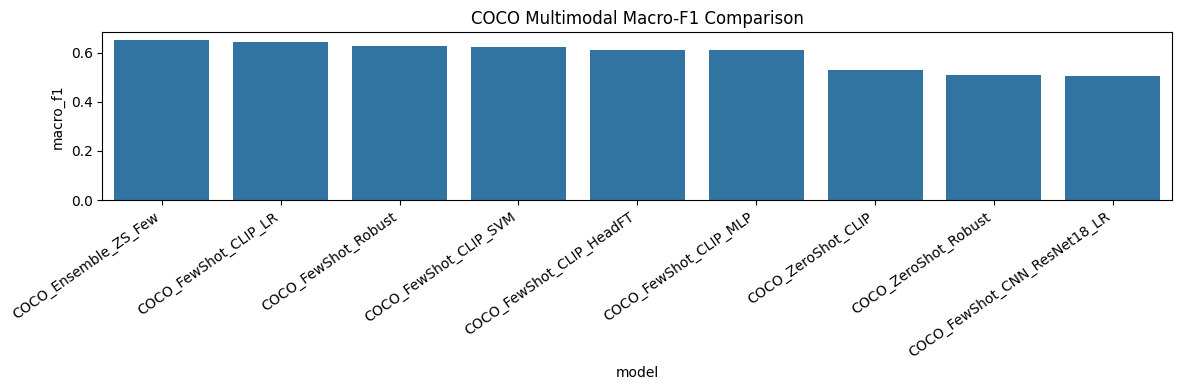

In [16]:
results = [
    {'model': 'COCO_ZeroShot_CLIP', **zs_metrics, 'ece': ece_zs},
    {'model': 'COCO_FewShot_CLIP_LR', **few_metrics, 'ece': ece_few},
    {'model': 'COCO_FewShot_CLIP_SVM', **svm_metrics, 'ece': np.nan},
    {'model': 'COCO_FewShot_CLIP_MLP', **mlp_metrics, 'ece': np.nan},
    {'model': 'COCO_FewShot_CNN_ResNet18_LR', **cnn_few_metrics, 'ece': ece_cnn},
    {'model': 'COCO_FewShot_CLIP_HeadFT', **clip_head_metrics, 'ece': np.nan},
    {'model': 'COCO_Ensemble_ZS_Few', **ens_metrics, 'ece': np.nan},
    {'model': 'COCO_ZeroShot_Robust', **rob_zs, 'ece': np.nan},
    {'model': 'COCO_FewShot_Robust', **rob_few, 'ece': np.nan},
]
res_df = pd.DataFrame(results).sort_values('macro_f1', ascending=False)
display(res_df)

OUT_DIR.mkdir(parents=True, exist_ok=True)
res_df.to_csv(OUT_DIR / 'coco_multimodal_results.csv', index=False)
with open(OUT_DIR / 'coco_multimodal_results.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

with open(OUT_DIR / 'coco_label_mapping.json', 'w', encoding='utf-8') as f:
    json.dump({'label2id': {c:int(i) for i,c in enumerate(le.classes_)}, 'id2label': {int(i):c for i,c in enumerate(le.classes_)}}, f, ensure_ascii=False, indent=2)

plt.figure(figsize=(12,4))
sns.barplot(data=res_df, x='model', y='macro_f1')
plt.xticks(rotation=35, ha='right')
plt.title('COCO Multimodal Macro-F1 Comparison')
plt.tight_layout()
plt.show()


=== PERFORMANCE SUMMARY ===


,Method,Accuracy,Macro-F1
4,Ensemble,0.672010,0.650280
1,Few-shot LR,0.662145,0.643413
3,CLIP Head FT,0.642417,0.611000
0,Zero-shot (VAPF),0.606658,0.530830
2,CNN (ResNet18),0.535142,0.506196


/tmp/ipykernel_1712/1076520013.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(class_names, rotation=30)


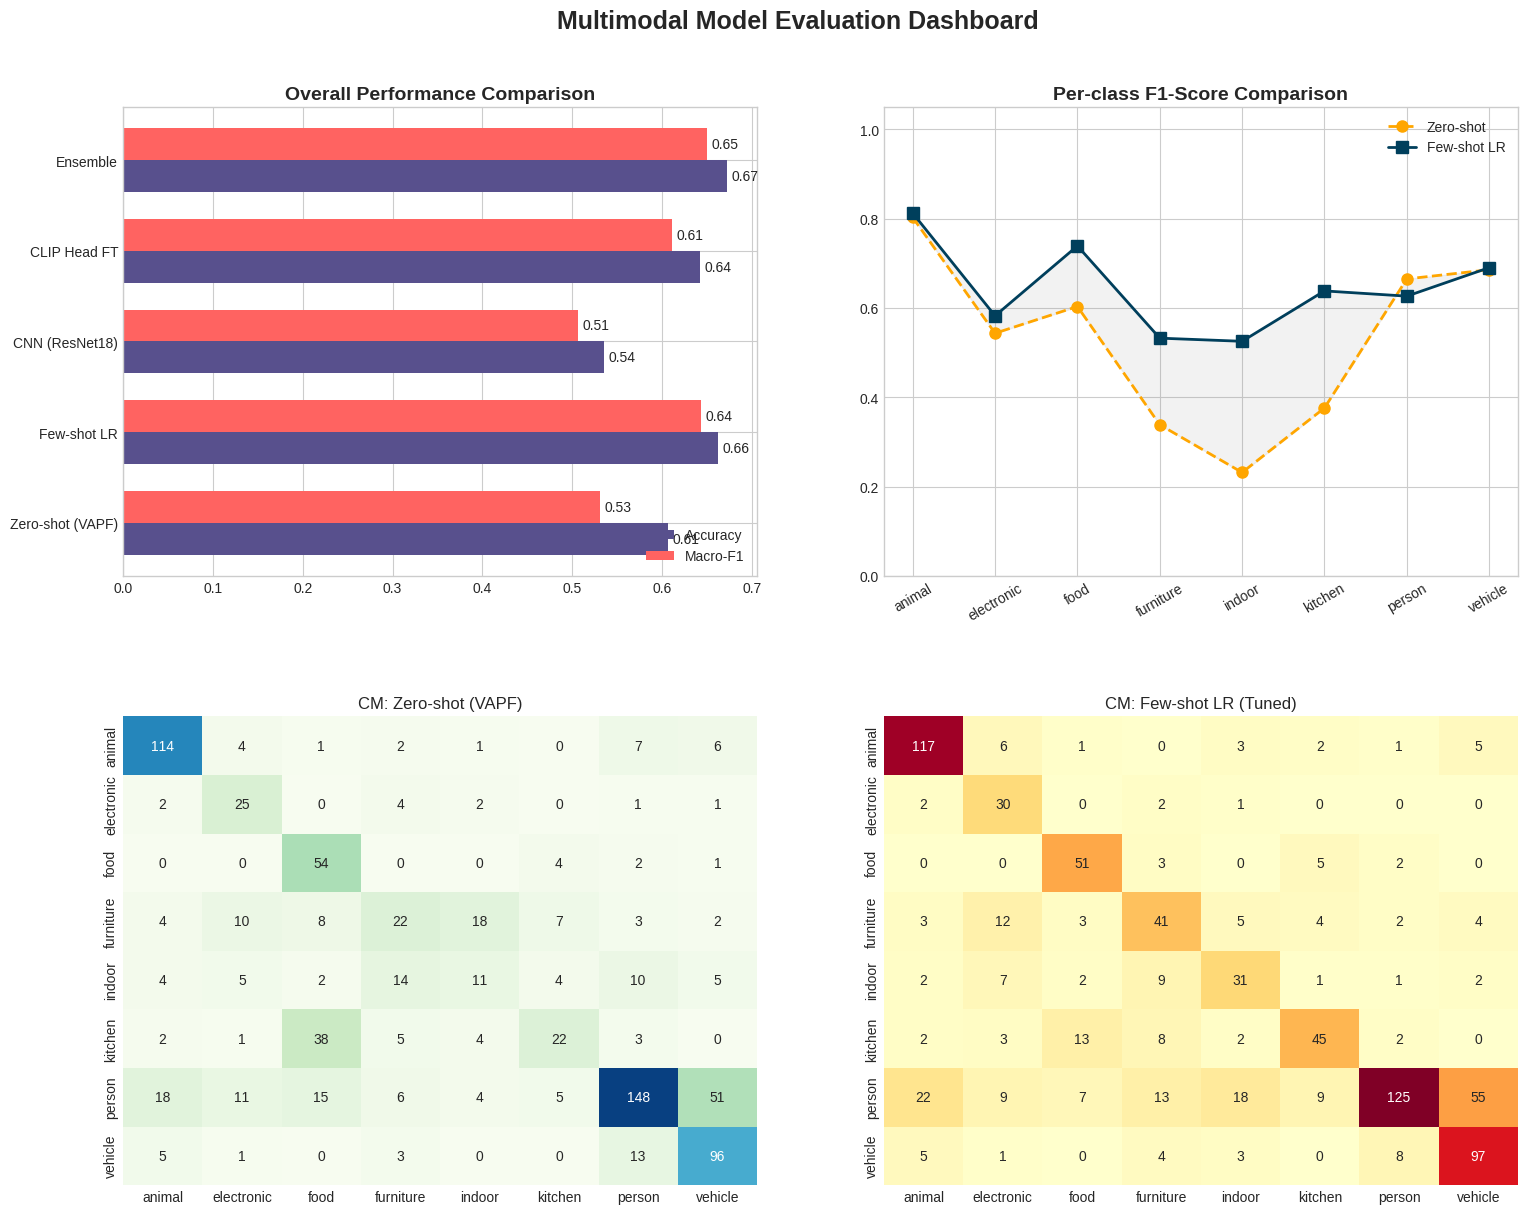

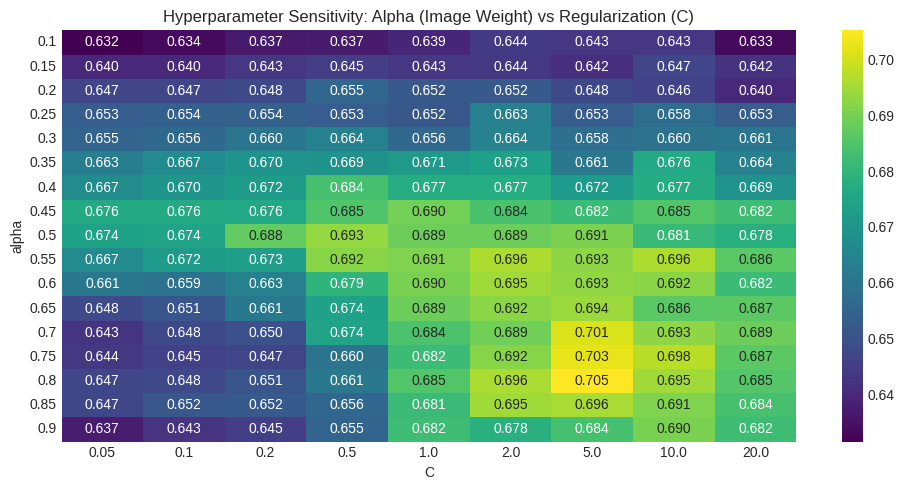

In [17]:
from sklearn.metrics import classification_report

# 1. Summary Table
report_df = pd.DataFrame([
    {'Method': 'Zero-shot (VAPF)', 'Accuracy': zs_metrics['accuracy'], 'Macro-F1': zs_metrics['macro_f1']},
    {'Method': 'Few-shot LR', 'Accuracy': few_metrics['accuracy'], 'Macro-F1': few_metrics['macro_f1']},
    {'Method': 'CNN (ResNet18)', 'Accuracy': cnn_few_metrics['accuracy'], 'Macro-F1': cnn_few_metrics['macro_f1']},
    {'Method': 'CLIP Head FT', 'Accuracy': clip_head_metrics['accuracy'], 'Macro-F1': clip_head_metrics['macro_f1']},
    {'Method': 'Ensemble', 'Accuracy': ens_metrics['accuracy'], 'Macro-F1': ens_metrics['macro_f1']},
])
print('=== PERFORMANCE SUMMARY ===')
display(report_df.sort_values('Macro-F1', ascending=False).style.background_gradient(cmap='Greens', subset=['Macro-F1']))

# 2. Plotting with new style
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.2)

# (A) Overall Metrics - Horizontal Bar Chart
ax1 = fig.add_subplot(gs[0, 0])
methods = report_df['Method'].tolist()
x = np.arange(len(methods))
width = 0.35
rects1 = ax1.barh(x - width/2, report_df['Accuracy'], width, label='Accuracy', color='#58508d')
rects2 = ax1.barh(x + width/2, report_df['Macro-F1'], width, label='Macro-F1', color='#ff6361')
ax1.set_yticks(x)
ax1.set_yticklabels(methods)
ax1.set_title('Overall Performance Comparison', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.bar_label(rects1, fmt='%.2f', padding=3)
ax1.bar_label(rects2, fmt='%.2f', padding=3)

# (B) Per-class F1-Score - Line Chart with Markers
ax2 = fig.add_subplot(gs[0, 1])
labels_idx = list(range(len(class_names)))
zs_f1_per = f1_score(y_test, zs_pred, average=None, labels=labels_idx)
fs_f1_per = f1_score(y_test, few_pred, average=None, labels=labels_idx)
ax2.plot(class_names, zs_f1_per, 'o--', label='Zero-shot', color='#ffa600', linewidth=2, markersize=8)
ax2.plot(class_names, fs_f1_per, 's-', label='Few-shot LR', color='#003f5c', linewidth=2, markersize=8)
ax2.set_ylim(0, 1.05)
ax2.set_title('Per-class F1-Score Comparison', fontsize=14, fontweight='bold')
ax2.set_xticklabels(class_names, rotation=30)
ax2.fill_between(class_names, zs_f1_per, fs_f1_per, color='gray', alpha=0.1)
ax2.legend()

# (C) Confusion Matrix Zero-shot (GnBu)
ax3 = fig.add_subplot(gs[1, 0])
cm_zs = confusion_matrix(y_test, zs_pred)
sns.heatmap(cm_zs, annot=True, fmt='d', cmap='GnBu', ax=ax3, xticklabels=class_names, yticklabels=class_names, cbar=False)
ax3.set_title('CM: Zero-shot (VAPF)', fontsize=12)

# (D) Confusion Matrix Few-shot (YlOrRd)
ax4 = fig.add_subplot(gs[1, 1])
cm_fs = confusion_matrix(y_test, few_pred)
sns.heatmap(cm_fs, annot=True, fmt='d', cmap='YlOrRd', ax=ax4, xticklabels=class_names, yticklabels=class_names, cbar=False)
ax4.set_title('CM: Few-shot LR (Tuned)', fontsize=12)

plt.suptitle('Multimodal Model Evaluation Dashboard', fontsize=18, fontweight='bold', y=0.95)
plt.show()

# 3. Tuning Heatmap if available
if 'few_tuning_df' in globals():
    plt.figure(figsize=(10, 5))
    pivot = few_tuning_df.pivot_table(index='alpha', columns='C', values='val_macro_f1')
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis')
    plt.title('Hyperparameter Sensitivity: Alpha (Image Weight) vs Regularization (C)')
    plt.tight_layout()
    plt.show()

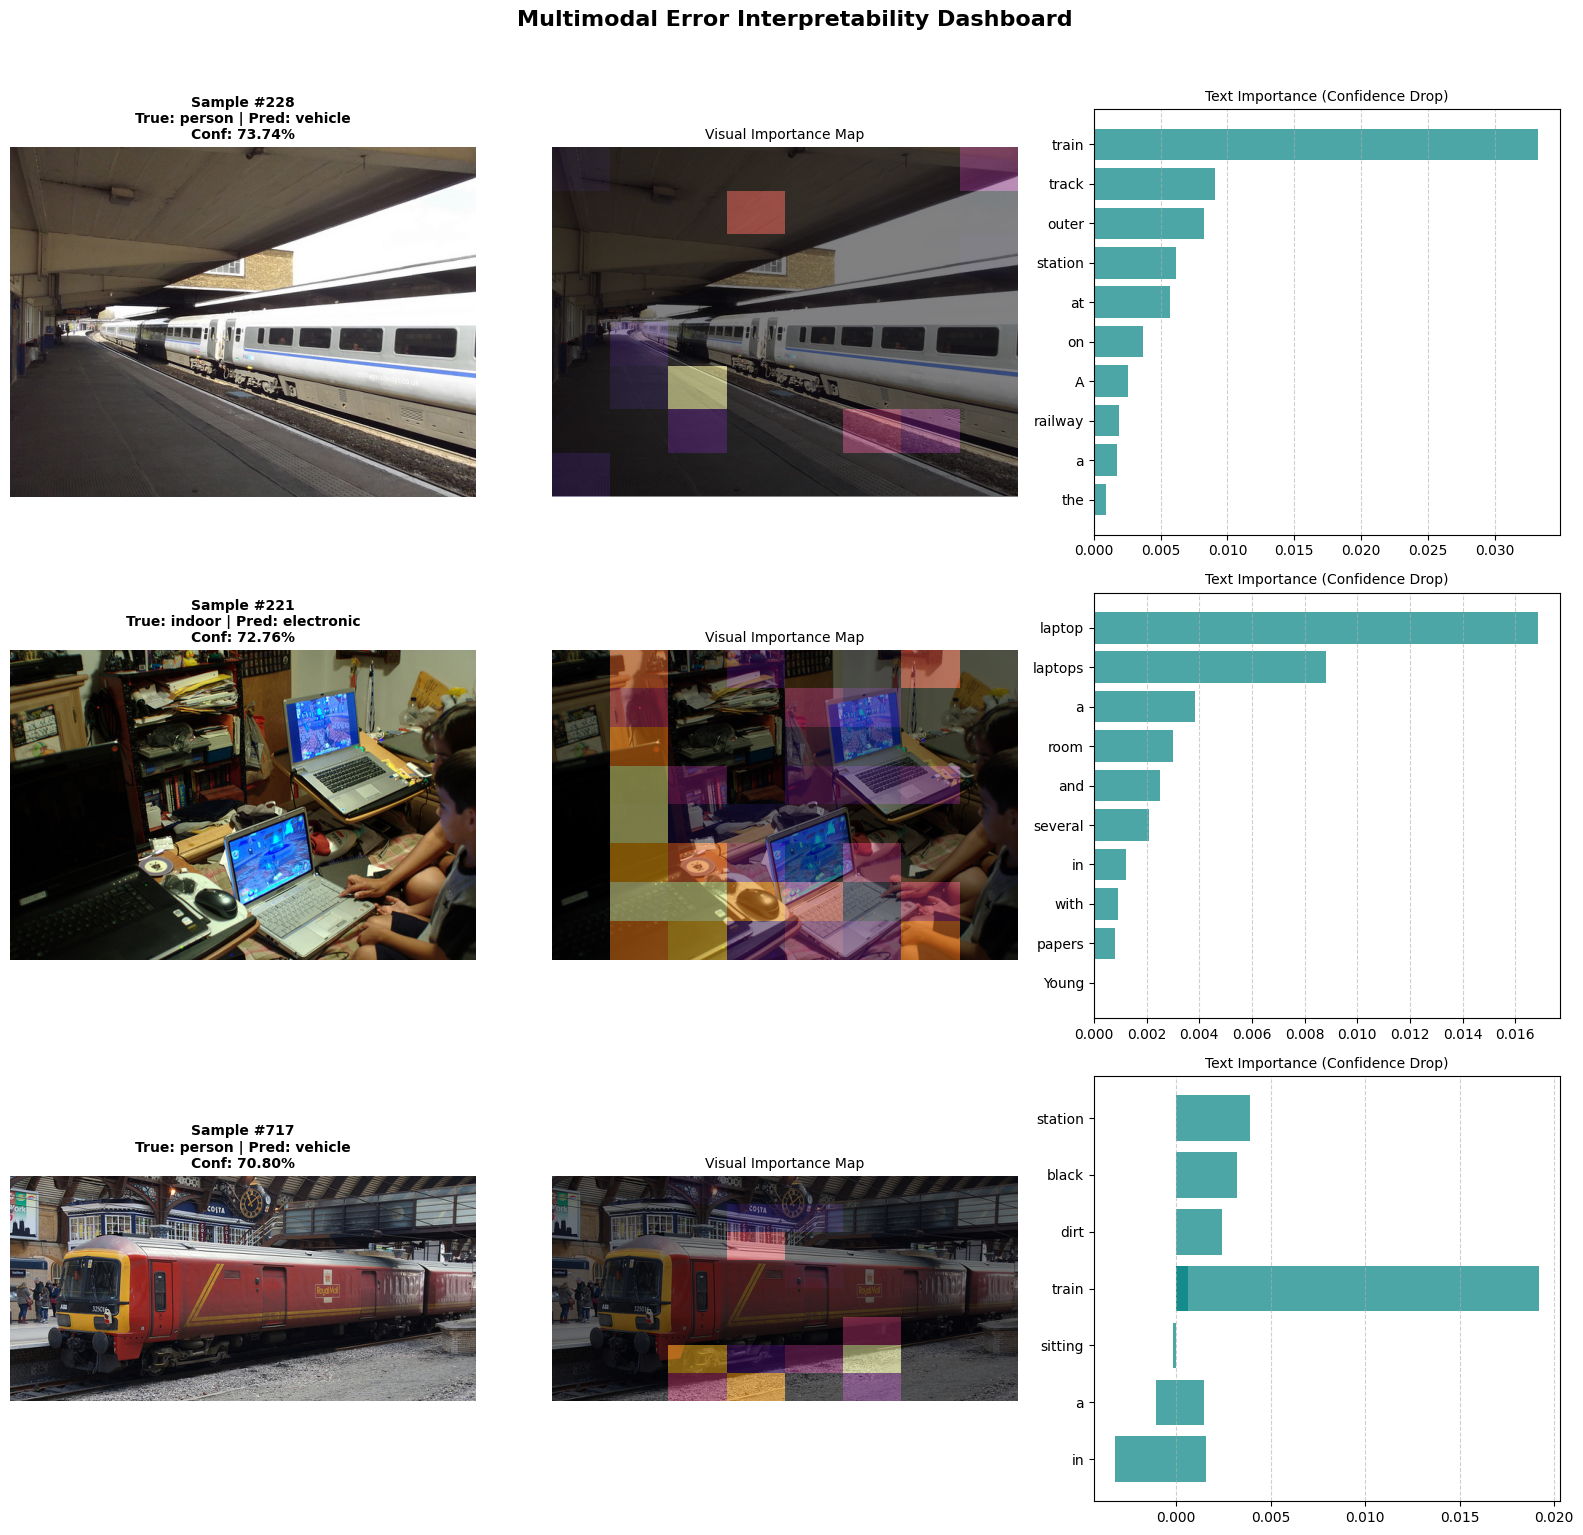

In [18]:
# Interpretability lỗi: token importance + occlusion heatmap
import re

def encode_single_clip(image, text):
    with torch.no_grad():
        in_img = clip_encode_batch(imgs=[image])
        in_img = {k: v.to(DEVICE) for k, v in in_img.items()}
        f_img = as_feature_tensor(clip_model.get_image_features(**in_img))

        in_txt = clip_encode_batch(txts=[text])
        in_txt = {k: v.to(DEVICE) for k, v in in_txt.items()}
        f_txt = as_feature_tensor(clip_model.get_text_features(**in_txt))

        f_img = f_img / f_img.norm(dim=-1, keepdim=True)
        f_txt = f_txt / f_txt.norm(dim=-1, keepdim=True)

    return f_img.cpu().numpy(), f_txt.cpu().numpy()

def predict_fewshot_from_sample(image, text, alpha=None):
    alpha = few_best['alpha'] if alpha is None else float(alpha)
    img_f, txt_f = encode_single_clip(image, text)
    fused = fuse_feats(img_f, txt_f, alpha=alpha)
    proba = few_clf.predict_proba(fused)[0]
    pred_idx = int(np.argmax(proba))
    return {
        'proba': proba,
        'pred_idx': pred_idx,
        'pred_label': class_names[pred_idx],
        'confidence': float(proba[pred_idx]),
        'fused': fused[0],
    }

def top_word_importance(image, text, target_idx=None, max_words=8):
    base = predict_fewshot_from_sample(image, text)
    target_idx = base['pred_idx'] if target_idx is None else int(target_idx)
    base_score = float(base['proba'][target_idx])

    words = re.findall(r"\w+|[^\w\s]", str(text))
    if len(words) <= 1:
        return pd.DataFrame([{'token': str(text), 'score_drop': 0.0}])

    rows = []
    for idx, token in enumerate(words):
        if not re.search(r'\w', token):
            continue
        reduced = words[:idx] + words[idx + 1:]
        reduced_text = ' '.join(reduced).replace(' ,', ',').replace(' .', '.')
        out = predict_fewshot_from_sample(image, reduced_text)
        rows.append({'token': token, 'score_drop': base_score - float(out['proba'][target_idx])})

    if len(rows) == 0:
        return pd.DataFrame([{'token': '(none)', 'score_drop': 0.0}])
    return pd.DataFrame(rows).sort_values('score_drop', ascending=False).head(max_words)

def image_occlusion_heatmap(image, text, target_idx=None, grid_size=7, fill_value=127):
    base = predict_fewshot_from_sample(image, text)
    target_idx = base['pred_idx'] if target_idx is None else int(target_idx)
    base_score = float(base['proba'][target_idx])

    img_np = np.array(image).copy()
    h, w = img_np.shape[:2]
    ys = np.linspace(0, h, grid_size + 1, dtype=int)
    xs = np.linspace(0, w, grid_size + 1, dtype=int)
    heat = np.zeros((grid_size, grid_size), dtype=np.float32)

    for gy in range(grid_size):
        for gx in range(grid_size):
            occluded = img_np.copy()
            y0, y1 = ys[gy], ys[gy + 1]
            x0, x1 = xs[gx], xs[gx + 1]
            occluded[y0:y1, x0:x1] = fill_value
            out = predict_fewshot_from_sample(Image.fromarray(occluded), text)
            heat[gy, gx] = max(0.0, base_score - float(out['proba'][target_idx]))

    if heat.max() > 0:
        heat = heat / heat.max()
    return heat, base

# Error table
error_mask = few_pred != y_test
error_idx = np.where(error_mask)[0]
error_df = pd.DataFrame({
    'idx': error_idx,
    'true_label': np.array(class_names)[y_test[error_idx]],
    'pred_label': np.array(class_names)[few_pred[error_idx]],
    'confidence': few_prob.max(axis=1)[error_idx],
    'text': test_df.iloc[error_idx]['text'].values,
}).sort_values('confidence', ascending=False).reset_index(drop=True)

selected_errors = error_df.head(min(3, len(error_df)))
if len(selected_errors) > 0:
    plt.style.use('default')
    fig, axes = plt.subplots(len(selected_errors), 3, figsize=(16, 5 * len(selected_errors)))
    if len(selected_errors) == 1: axes = np.expand_dims(axes, axis=0)

    for row_id, (_, err_row) in enumerate(selected_errors.iterrows()):
        idx = int(err_row['idx'])
        sample = test_df.iloc[idx]
        image = Image.open(sample['image_path']).convert('RGB')
        text = sample['text']

        target_idx = class_names.index(err_row['pred_label'])
        heat, base = image_occlusion_heatmap(image, text, target_idx=target_idx, grid_size=8)
        token_imp = top_word_importance(image, text, target_idx=target_idx, max_words=10)

        # Original Image
        axes[row_id, 0].imshow(image)
        axes[row_id, 0].set_title(f"Sample #{idx}\nTrue: {err_row['true_label']} | Pred: {err_row['pred_label']}\nConf: {base['confidence']:.2%}", fontsize=10, fontweight='bold')
        axes[row_id, 0].axis('off')

        # Occlusion Heatmap
        axes[row_id, 1].imshow(image)
        im_heat = axes[row_id, 1].imshow(heat, cmap='inferno', alpha=0.5, extent=(0, image.size[0], image.size[1], 0))
        axes[row_id, 1].set_title('Visual Importance Map', fontsize=10)
        axes[row_id, 1].axis('off')

        # Token Importance
        token_imp_plot = token_imp.sort_values('score_drop', ascending=True)
        axes[row_id, 2].barh(token_imp_plot['token'], token_imp_plot['score_drop'], color='#008080', alpha=0.7)
        axes[row_id, 2].set_title('Text Importance (Confidence Drop)', fontsize=10)
        axes[row_id, 2].grid(axis='x', linestyle='--', alpha=0.6)

    plt.suptitle('Multimodal Error Interpretability Dashboard', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


=== K-SHOT BENCHMARK RESULTS ===


,K,test_accuracy,test_macro_f1,runtime_sec
0,8,0.653514,0.614439,6.190575
1,16,0.662145,0.643413,1.715269
2,32,0.681874,0.669126,2.350408


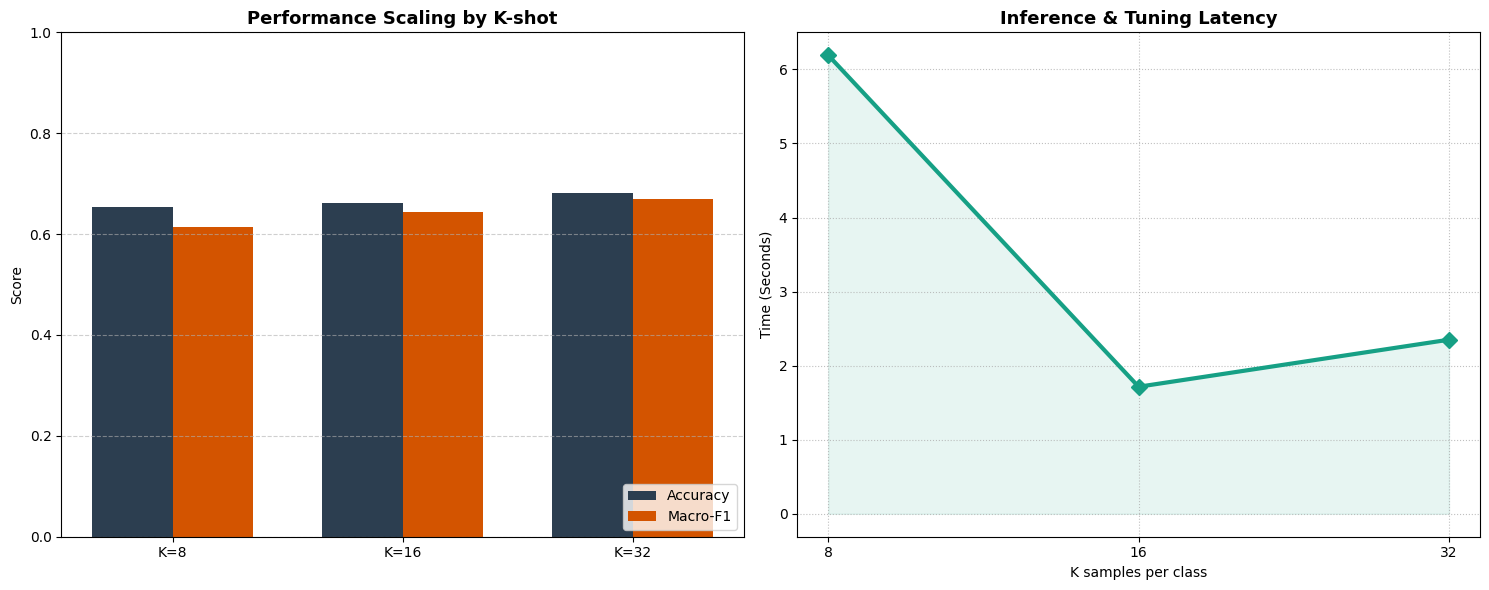

In [19]:
# Benchmark theo K-shot
import time

def make_kshot_indices(y, k=16, seed=42):
    rng = np.random.default_rng(seed)
    idx = []
    for c in sorted(np.unique(y)):
        c_idx = np.where(y == c)[0].copy()
        rng.shuffle(c_idx)
        idx.extend(c_idx[:min(k, len(c_idx))].tolist())
    return np.array(idx, dtype=np.int64)

k_values = [8, 16, 32]
bench_alpha_grid = np.round(np.linspace(0.2, 0.8, 7), 2).tolist()
bench_c_grid = [0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]

kshot_rows = []
for k_try in k_values:
    start_time = time.perf_counter()
    idx_k = make_kshot_indices(y_train, k=k_try, seed=CFG['seed'])
    yk_train = y_train[idx_k]

    tune_idx = val_tune_idx if 'val_tune_idx' in globals() else np.arange(len(y_val))
    yk_val = y_val[tune_idx]

    best_k = {'f1': -1.0, 'alpha': None, 'C': None, 'clf': None}
    for alpha_try in bench_alpha_grid:
        Xk_train = fuse_feats(img_train_f[idx_k], txt_train_f[idx_k], alpha=alpha_try)
        Xk_val = fuse_feats(img_val_f[tune_idx], txt_val_f[tune_idx], alpha=alpha_try)

        for c_try in bench_c_grid:
            clf_try = make_lr(c_try)
            clf_try.fit(Xk_train, yk_train)
            pred_k_val = clf_try.predict(Xk_val)
            f1_k_val = f1_score(yk_val, pred_k_val, average='macro')
            if f1_k_val > best_k['f1']:
                best_k = {'f1': float(f1_k_val), 'alpha': float(alpha_try), 'C': float(c_try), 'clf': clf_try}

    Xk_test = fuse_feats(img_test_f, txt_test_f, alpha=best_k['alpha'])
    yk_pred = best_k['clf'].predict(Xk_test)

    acc_k = accuracy_score(y_test, yk_pred)
    f1_k = f1_score(y_test, yk_pred, average='macro')
    elapsed = time.perf_counter() - start_time

    kshot_rows.append({
        'K': int(k_try),
        'test_accuracy': float(acc_k),
        'test_macro_f1': float(f1_k),
        'runtime_sec': float(elapsed)
    })

kshot_df = pd.DataFrame(kshot_rows)
print('\n=== K-SHOT BENCHMARK RESULTS ===')
display(kshot_df)

# New Visualization Layout
plt.style.use('seaborn-v0_8-muted')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Grouped Bar Chart for performance
x_labels = kshot_df['K'].astype(str)
x_idx = np.arange(len(x_labels))
width = 0.35

axes[0].bar(x_idx - width/2, kshot_df['test_accuracy'], width, label='Accuracy', color='#2c3e50')
axes[0].bar(x_idx + width/2, kshot_df['test_macro_f1'], width, label='Macro-F1', color='#d35400')

axes[0].set_title('Performance Scaling by K-shot', fontsize=13, fontweight='bold')
axes[0].set_xticks(x_idx)
axes[0].set_xticklabels([f"K={k}" for k in x_labels])
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.0)
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Right: Line Plot for Runtime
axes[1].plot(x_labels, kshot_df['runtime_sec'], marker='D', markersize=8, color='#16a085', linewidth=3)
axes[1].fill_between(x_labels, kshot_df['runtime_sec'], color='#16a085', alpha=0.1)
axes[1].set_title('Inference & Tuning Latency', fontsize=13, fontweight='bold')
axes[1].set_xlabel('K samples per class')
axes[1].set_ylabel('Time (Seconds)')
axes[1].grid(True, linestyle=':', alpha=0.8)

plt.tight_layout()
plt.show()

In [20]:
%pip install -q gradio

In [21]:
# Mini demo UI: 1 Gradio app cho cả Few-shot và Zero-shot
import textwrap
import numpy as np
import pandas as pd

try:
    import gradio as gr
except Exception:
    print('Thiếu gradio. Cài bằng: %pip install gradio')
    raise


def _missing_fewshot():
    required = ['few_clf', 'few_best', 'class_names', 'predict_fewshot_from_sample']
    return [k for k in required if k not in globals()]


def _missing_zeroshot():
    required = ['vapf_best_alpha', 'class_names', 'softmax_np', 'encode_single_clip', 'fuse_feats']
    missing = [k for k in required if k not in globals()]
    if ('class_proto' not in globals()) and ('class_emb' not in globals()):
        missing.append('class_proto/class_emb')
    return missing


def run_fewshot_demo(image, caption, topk):
    missing = _missing_fewshot()
    if len(missing) > 0:
        return f"Chưa thể chạy Few-shot demo vì thiếu biến: {missing}", pd.DataFrame(columns=['label', 'probability'])

    if image is None:
        return 'Vui lòng upload ảnh trước.', pd.DataFrame(columns=['label', 'probability'])

    text = (caption or '').strip()
    if len(text) == 0:
        text = 'a generic scene with people and objects'

    pred = predict_fewshot_from_sample(image, text)
    proba = pred['proba']
    k = int(topk)
    order = np.argsort(-proba)[:k]
    table = pd.DataFrame({
        'label': [class_names[i] for i in order],
        'probability': [float(proba[i]) for i in order],
    })
    wrapped = '\n'.join(textwrap.wrap(text, width=60))
    summary = f"Few-shot pred: {pred['pred_label']} (conf={pred['confidence']:.3f})\nCaption: {wrapped}"
    return summary, table


def run_zeroshot_demo(image, caption, topk):
    missing = _missing_zeroshot()
    if len(missing) > 0:
        return f"Chưa thể chạy Zero-shot demo vì thiếu biến: {missing}", pd.DataFrame(columns=['label', 'probability'])

    if image is None:
        return 'Vui lòng upload ảnh trước.', pd.DataFrame(columns=['label', 'probability'])

    text = (caption or '').strip()
    if len(text) == 0:
        text = 'a generic scene with people and objects'

    alpha = float(vapf_best_alpha)
    class_proto_local = globals().get('class_proto', globals().get('class_emb', None))

    img_f, txt_f = encode_single_clip(image, text)
    fused = fuse_feats(img_f, txt_f, alpha=alpha)
    logits = fused @ class_proto_local.T
    prob = softmax_np(logits)[0]
    pred_idx = int(np.argmax(prob))

    k = int(topk)
    order = np.argsort(-prob)[:k]
    table = pd.DataFrame({
        'label': [class_names[i] for i in order],
        'probability': [float(prob[i]) for i in order],
    })
    wrapped = '\n'.join(textwrap.wrap(text, width=60))
    summary = f"Zero-shot pred: {class_names[pred_idx]} (conf={float(prob[pred_idx]):.3f}, alpha={alpha:.2f})\nCaption: {wrapped}"
    return summary, table


with gr.Blocks() as demo_mm:
    gr.Markdown('### Mini Demo Multimodal (Few-shot + Zero-shot)')

    with gr.Tabs():
        with gr.TabItem('Few-shot LR tuned'):
            with gr.Row():
                image_few = gr.Image(type='pil', label='Upload ảnh')
                with gr.Column():
                    caption_few = gr.Textbox(label='Caption', placeholder='Nhập caption tiếng Anh...', lines=4)
                    topk_few = gr.Slider(minimum=1, maximum=5, step=1, value=3, label='Top-k')
                    btn_few = gr.Button('Predict Few-shot', variant='primary')
            out_text_few = gr.Textbox(label='Kết quả Few-shot')
            out_table_few = gr.Dataframe(label='Top-k probabilities (Few-shot)', wrap=True)
            btn_few.click(
                fn=run_fewshot_demo,
                inputs=[image_few, caption_few, topk_few],
                outputs=[out_text_few, out_table_few],
            )

        with gr.TabItem('Zero-shot + VAPF'):
            with gr.Row():
                image_zs = gr.Image(type='pil', label='Upload ảnh')
                with gr.Column():
                    caption_zs = gr.Textbox(label='Caption', placeholder='Nhập caption tiếng Anh...', lines=4)
                    topk_zs = gr.Slider(minimum=1, maximum=5, step=1, value=3, label='Top-k')
                    btn_zs = gr.Button('Predict Zero-shot', variant='primary')
            out_text_zs = gr.Textbox(label='Kết quả Zero-shot')
            out_table_zs = gr.Dataframe(label='Top-k probabilities (Zero-shot)', wrap=True)
            btn_zs.click(
                fn=run_zeroshot_demo,
                inputs=[image_zs, caption_zs, topk_zs],
                outputs=[out_text_zs, out_table_zs],
            )


demo_mm.launch(share=False, prevent_thread_lock=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>